# KDD Process Volcano Data Analysis

**Dataset :**  Volcano Events

**Team Members:**
- Hannah-May LITTIERE
- Timothée JOLIOT
- Axel JUILLARD
- Sandrine DANIEL
- Léo-Paul CHAUVIGNE

## Imports

In [605]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from prophet import Prophet
import plotly.graph_objects as go 
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from dash import Dash, dcc, html, Input, Output

# 1. Data Collection and Exploration

In this section, we implement the first step of the KDD process: Data Collection and Preprocessing. The dataset used is the "Significant Volcanic Eruption Database" provided by the National Center for Environmental Information (NCEI). It contains the data for over 600 eruptions from 4360 BC to the present. Each eruption is detailed with attributes such as location, time, VEI (Volcanic Explosivity Index), and impact metrics (deaths, damage).

**Objectives of this step:**
1.  Load the data into a Pandas DataFrame.
2.  Clean the data by handling missing values and correct data types.
3.  Summarize the data (shape, types, missing values) to understand its quality.
4.  Establish rankings between variables to identify initial patterns.

In [606]:
#Display settings to ensure we see all columns during exploration
pd.set_option('display.max_columns', None)

In [607]:
def load_raw_data(filepath):
    """
    Reads the TSV file.
    Input: filepath (str)
    Output: raw dataframe (pd.DataFrame)
    """
    try:
        df = pd.read_csv(filepath, sep='\t')
        print("File loaded.")
        return df
    except FileNotFoundError:
        print("File not found. Please check the path.")
        return None


# Place the volcano-events.tsv file in the same directory as this notebook
file_path = "volcano-events.tsv"
df_raw = load_raw_data(file_path)

# We display the first 5 rows of the dataframe for a first peak at the data
df_raw.head(5)

File loaded.


,Search Parameters,Year,Mo,Dy,Tsu,Eq,Name,Location,Country,Latitude,Longitude,Elevation (m),Type,VEI,Agent,Deaths,Death Description,Missing,Missing Description,Injuries,Injuries Description,Damage ($Mil),Damage Description,Houses Destroyed,Houses Destroyed Description,Total Deaths,Total Death Description,Total Missing,Total Missing Description,Total Injuries,Total Injuries Description,Total Damage ($Mil),Total Damage Description,Total Houses Destroyed,Total Houses Destroyed Description
0,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,-4360.0,NaN,NaN,NaN,NaN,Macauley,Kermadec Is,New Zealand,-30.210,-178.475,238.0,Caldera,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,-4350.0,NaN,NaN,NaN,NaN,Kikai,Ryukyu Is,Japan,30.793,130.305,704.0,Caldera,7.0,P,NaN,3.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,3.0
3,NaN,-4050.0,NaN,NaN,NaN,NaN,Masaya,Nicaragua,Nicaragua,11.985,-86.165,594.0,Caldera,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,-4000.0,NaN,NaN,NaN,NaN,Witori,New Britain-SW Pac,Papua New Guinea,-5.576,150.516,724.0,Caldera,6.0,T,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


With this first look at the data we notice a few things:
- The first row is filled with NaNs and the search parameter value is '[]'. It seems this row is an artefact, we will remove it.
- There appears to be a lot of NaNs in the data, we will need to take this into account.
- The date data is split between 3 columns, 'Year', 'Mo' and 'Dy'. We will need to take this into account.
- In addition when looking at the Year column we also see that there are negative years, we will therefore need to add a way to display Years with B.C. and A.D. for readability in the dashboard.
- The agent column here has a value 'P' and a value 'T', these are characteristic and each letter stands for something, we will therefore have to understand what each letter stands for.

In [608]:
df_raw['Agent'].unique()

array([nan, 'P', 'T', 'P,T', 'W', 'M', 'T,L', 'S,W', 'F', 'I', 'T,F',
       'P,T,M', 'A', 'L', 'E', 'M,T', 'S', 'P,E,M', 'G,W,T', 'G,T',
       'T,P,W,I', 'T,P', 'm', 'G', 'W,S', 'W,T', 'P,I', 'T,W,I', 'F,P,I',
       'W,A', 'M,L,T,G', 'T,W', 'T, m', 'P,M', 'P,M,E', 'P,W,A,I', 'G,I',
       'W,M', 'T,A', 'L,G', 'W,P,I', 'A,P', 'I,M', '?', 'W,P', 'P,W',
       'T,G', 'P,m', 'I,S,A,T', 'S,L', 'P,W,T', 'A,F', 'P,T,W,I', 'E,I',
       'T,L,I', 'P,T,M,A', 'M,m,P', 'P,M,I', 'P,T,G', 'M,P', 'T,m', 'T,M',
       'P,L', 'P,M,T', 'A,T,W', 'P,T,M,S', 'I,T', 'L,T', 'P,m,I', 'T,I',
       'A,W', 'T,G,M', 'S,T,G', 'A,P,T', 'P,T,W', 'G,W, S', 'L,I,S',
       'M,G,T', 'T,P,L'], dtype=object)

Looking in further detail at the agent column we can see that sometimes an eruption has multiple agents. Here the agents are separated by a comma. We will need to seperate them into binary columns to better analyse them.

After further research we can see that the agents are as follows:
Based on the NOAA Significant Volcanic Eruption Database and the classification standards by Simkin and Siebert (1994), the Agent column indicates the specific volcanic hazard or phenomenon that caused fatalities, injuries, or damage during an eruption. 

- A : Avalanche (Debris)
- E : Electrical (Lightning)
- F : Floods
- G : Gas
- I : Indirect (Starvation, Disease)
- L : Lava Flow
- M : Mudflow (Lahar) (Primary) (upper case indicates the event happened at the same time as the eruption)
- m : Mudflow (Lahar) (Secondary) (lower case indicates the event happened after the eruption)
- P : Pyroclastic Flow
- S : Seismic
- T : Tephra/Ash fall (falling volcanic rock and ash).
- W : Waves


Now we notice something interesting. Tsunamis (Waves) and Earthquakes (Seismic) are listed in agents aswell as there standalone columns although this is discutable because the names are not exactly the same. We therefore need to check if the agents and the standalone columns' values overlap before continuing.

In [609]:
def divide_agents(df):
    """
    Splits the comma-separated 'Agent' column into individual binary columns for easier analysis.
    intput: df (pd.DataFrame)
    output: df_agent_divided (pd.DataFrame)
    """

    # Convert to string, handle NaNs as empty strings, and remove spaces (e.g. "T, m" -> "T,m")
    agents_cleaned = df['Agent'].fillna('').astype(str).str.replace(' ', '')
    
    # We Split and Create the Binary Columns
    # 'sep=,' tells pandas to treat comma as the delimiter
    agent_dummies = agents_cleaned.str.get_dummies(sep=',')
    
    # Rename columns for clarity (e.g. "P" -> "Agent_P")
    agent_dummies = agent_dummies.add_prefix('Agent_')
    
    # Concatenate the new columns to the original dataframe
    df_agent_divided = pd.concat([df, agent_dummies], axis=1)

    df_agent_divided = df_agent_divided.drop(columns=['Agent'])
    
    return df_agent_divided

df_agent_divided = divide_agents(df_raw)
df_agent_divided.dtypes

Search Parameters                      object
Year                                  float64
Mo                                    float64
Dy                                    float64
Tsu                                   float64
Eq                                    float64
Name                                   object
Location                               object
Country                                object
Latitude                              float64
Longitude                             float64
Elevation (m)                         float64
Type                                   object
VEI                                   float64
Deaths                                float64
Death Description                     float64
Missing                               float64
Missing Description                   float64
Injuries                              float64
Injuries Description                  float64
Damage ($Mil)                         float64
Damage Description                

In [610]:
def check_tsu_eq_consistency(df_agent_divided):
    """
    Specialized EDA function to check whether tsunami and earthquake data overlaps with the agent column. We also include a check to see if floods overlap with tsunamis as tsunamis could also be considered as causing floods.
    Input: df_agent_divided (pd.DataFrame) with agent columns divided
    Output: None
    """
    
    # We count the number of non-null values in the 'Tsu' and 'Eq' columns
    tsu_col_count = df_agent_divided['Tsu'].notna().sum()
    eq_col_count = df_agent_divided['Eq'].notna().sum()

    # We count the number of 'T', 'S', 'W', and 'F' codes in the 'Agent' column
    agent_S_col_count = df_agent_divided['Agent_S'].sum()
    agent_W_col_count = df_agent_divided['Agent_W'].sum()
    agent_F_col_count = df_agent_divided['Agent_F'].sum() # Added Flood count

    # Print the counts
    print(f"\nCOUNTS:")
    print(f"Total non-null 'Tsu' column values: {tsu_col_count}")
    print(f"Total 'W' (Waves) codes in Agent:   {agent_W_col_count}")
    print(f"Total 'F' (Floods) codes in Agent:  {agent_F_col_count}\n") # Added Flood count print

    print(f"Total non-null 'Eq' column values:  {eq_col_count}")
    print(f"Total 'S' (Seismic) codes in Agent: {agent_S_col_count}\n")

    

    # Now we check if the columns match
    print(f"\nCONSISTENCY CHECK:")
    
    # Check Tsunami (Agent_W vs Tsu) 
    # Mismatch A: Has 'Tsu' Data (Not Null) BUT 'Agent_W' is 0
    mismatch_tsu_A = df_agent_divided[df_agent_divided['Tsu'].notna() & (df_agent_divided['Agent_W'] == 0)]
    
    # Mismatch B: Has 'Agent_W' (== 1) BUT 'Tsu' is Missing (NaN)
    mismatch_tsu_B = df_agent_divided[(df_agent_divided['Agent_W'] == 1) & df_agent_divided['Tsu'].isna()]

    if mismatch_tsu_A.empty and mismatch_tsu_B.empty:
        print("Tsunami Data (Agent_W): The data is consistent.")
        print(" Every row with a Tsunami flag (W) has a corresponding 'Tsu' data and vice versa.")
    else:
        print("Tsunami Data (Agent_W): The data is not consistent.")
        if not mismatch_tsu_A.empty:
            print(f"   - {len(mismatch_tsu_A)} rows have 'Tsu' data but are missing the 'W' agent.")
        if not mismatch_tsu_B.empty:
            print(f"   - {len(mismatch_tsu_B)} rows have 'W' agent but are missing 'Tsu' data.")

    # Check Flood (Agent_F vs Tsu) - Added consistency check for floods and tsunamis
    # Mismatch A: Has 'Tsu' Data (Not Null) BUT 'Agent_F' is 0
    mismatch_flood_tsu_A = df_agent_divided[df_agent_divided['Tsu'].notna() & (df_agent_divided['Agent_F'] == 0)]
    
    # Mismatch B: Has 'Agent_F' (== 1) BUT 'Tsu' is Missing (NaN)
    mismatch_flood_tsu_B = df_agent_divided[(df_agent_divided['Agent_F'] == 1) & df_agent_divided['Tsu'].isna()]

    print(f"\n")
    if mismatch_flood_tsu_A.empty and mismatch_flood_tsu_B.empty:
        print("Flood Data (Agent_F) vs Tsunami Data (Tsu): The data is consistent.")
        print(" Every row with a Flood flag (F) has corresponding 'Tsu' data and vice versa.")
    else:
        print("Flood Data (Agent_F) vs Tsunami Data (Tsu): The data is not consistent.")
        if not mismatch_flood_tsu_A.empty:
            print(f"   - {len(mismatch_flood_tsu_A)} rows have 'Tsu' data but are missing the 'F' agent.")
        if not mismatch_flood_tsu_B.empty:
            print(f"   - {len(mismatch_flood_tsu_B)} rows have 'F' agent but are missing 'Tsu' data.")


    # Check Earthquake (Agent_S vs Eq) 

    # Mismatch A: Has 'Eq' Data (Not Null) BUT 'Agent_S' is 0
    mismatch_eq_A = df_agent_divided[df_agent_divided['Eq'].notna() & (df_agent_divided['Agent_S'] == 0)]
    
    # Mismatch B: Has 'Agent_S' (== 1) BUT 'Eq' is Missing (NaN)
    mismatch_eq_B = df_agent_divided[(df_agent_divided['Agent_S'] == 1) & df_agent_divided['Eq'].isna()]

    print(f"\n")
    if mismatch_eq_A.empty and mismatch_eq_B.empty:
        print("Earthquake Data: The data is consistent.")
        print(" Every row with an Earthquake flag has a corresponding 'S' agent and vice versa.")
    else:
        print("Earthquake Data: The data is not consistent.")
        if not mismatch_eq_A.empty:
            print(f"   - {len(mismatch_eq_A)} rows have 'Eq' data but are missing the 'S' agent.")
        if not mismatch_eq_B.empty:
            print(f"   - {len(mismatch_eq_B)} rows have 'S' agent but are missing 'Eq' data.")

# We run the function on df_agent_divided
check_tsu_eq_consistency(df_agent_divided)


COUNTS:
Total non-null 'Tsu' column values: 182
Total 'W' (Waves) codes in Agent:   64
Total 'F' (Floods) codes in Agent:  11

Total non-null 'Eq' column values:  79
Total 'S' (Seismic) codes in Agent: 25


CONSISTENCY CHECK:
Tsunami Data (Agent_W): The data is not consistent.
   - 119 rows have 'Tsu' data but are missing the 'W' agent.
   - 1 rows have 'W' agent but are missing 'Tsu' data.


Flood Data (Agent_F) vs Tsunami Data (Tsu): The data is not consistent.
   - 182 rows have 'Tsu' data but are missing the 'F' agent.
   - 11 rows have 'F' agent but are missing 'Tsu' data.


Earthquake Data: The data is not consistent.
   - 62 rows have 'Eq' data but are missing the 'S' agent.
   - 8 rows have 'S' agent but are missing 'Eq' data.


This result is again interesting, almost all Tsunamis are associated with with waves and almost all earthquakes are associated with seismic activity even though there are a few outliers. Whatmore is that all floods happen without tsunamis and vice versa therefor tsunamis and floods are not associated with each other in this dataset.

Allthough tsunamis and waves overlapp and earthquakes and seismic activity overlap, we will keep them separate to better understand the data.

In [611]:
def show_structure(df):
    """
    Prints the shape and data types of the dataset.
    Input: df (pd.DataFrame)
    """ 
    rows, cols = df.shape
    print(f"Number of Rows: {rows}")
    print(f"Number of Columns: {cols}")
 
    print("Data Types:")
    print(df.dtypes)

show_structure(df_agent_divided)

Number of Rows: 888
Number of Columns: 47
Data Types:
Search Parameters                      object
Year                                  float64
Mo                                    float64
Dy                                    float64
Tsu                                   float64
Eq                                    float64
Name                                   object
Location                               object
Country                                object
Latitude                              float64
Longitude                             float64
Elevation (m)                         float64
Type                                   object
VEI                                   float64
Deaths                                float64
Death Description                     float64
Missing                               float64
Missing Description                   float64
Injuries                              float64
Injuries Description                  float64
Damage ($Mil)             

Looking at the dtypes of the data we notice a few more things:

- The 'Tsu' and 'Eq' columns which stand for Tsunami and Earthquake are of type float64. They probably are binary columns, so they could be converted to boolean or just treated as such. We will still need to check the data to be sure.
- The date columns 'Year', 'Mo', and 'Dy' are of type float64. This is counter-intuitive for date components (which should be integers) and confirms the presence of missing values (NaN). In pandas, a column of integers containing even a single NaN is automatically cast to float.
- The columns ending in "Description" (e.g., Death Description, Damage Description, Houses Destroyed Description) are also float64. This is a significant finding: it implies these columns contain numeric codes (likely ordinal scales like 1, 2, 3, 4) rather than actual text descriptions. If they contained text, their dtype would be object. They also might have NaNs, which we will need to check.
- The impact columns like Deaths, Injuries, and Houses Destroyed are float64 as well. This reinforces that we must distinguish between 0 (confirmed no casualties) and NaN (unknown data). Treating NaN as 0 without verification could dangerously skew the analysis (e.g., assuming an ancient eruption had 0 deaths just because records are missing).
- Total Damage is in millions of US dollars, we will need to be careful to not forget that.

We have several pairs of columns: Deaths vs Total Deaths, Missing vs Total Missing, etc.
We needto understand the relationship between them. Logically, the 'Total' column should represent the sum of direct and indirect effects ( Tsunamis, Earthquakes), so it should be greater than or equal to the 'Normal' column.

In [612]:
def analyze_total_vs_normal(df):
    """
    Analyzes the relationship between 'Normal' columns (e.g., Deaths) and 'Total' columns (e.g., Total Deaths),
    and also compares their corresponding 'Description' columns.
    Provides detailed counts for different comparison scenarios, including potential anomalies.
    """
    numerical_pairs = [
        ('Deaths', 'Total Deaths'),
        ('Missing', 'Total Missing'),
        ('Injuries', 'Total Injuries'),
        ('Damage ($Mil)', 'Total Damage ($Mil)'),
        ('Houses Destroyed', 'Total Houses Destroyed')
    ]

    definition_pairs = [
        ('Death Description', 'Total Death Description'),
        ('Missing Description', 'Total Missing Description'),
        ('Injuries Description', 'Total Injuries Description'),
        ('Damage Description', 'Total Damage Description'),
        ('Houses Destroyed Description', 'Total Houses Destroyed Description')
    ]

    print("--- Numerical Column Comparison ---")
    numerical_headers = [
        'Normal Column', 'Total Column', 'Both Present',
        'Normal == Total', 'Normal < Total', 'Normal > Total (Anomaly)'
    ]
    print(f"{numerical_headers[0]:<20} | {numerical_headers[1]:<25} | {numerical_headers[2]:<15} | {numerical_headers[3]:<18} | {numerical_headers[4]:<18} | {numerical_headers[5]}")
    print("-" * 140)

    for normal_col, total_col in numerical_pairs:
        if normal_col not in df.columns or total_col not in df.columns:
            print(f"{normal_col:<20} | {total_col:<25} | {'N/A':<15} | {'N/A':<18} | {'N/A':<18} | {'N/A'} (Columns not found)")
            continue

        # Filter to rows where both values are present
        both_present_df = df.dropna(subset=[normal_col, total_col])
        count_both_present = len(both_present_df)

        if count_both_present == 0:
            print(f"{normal_col:<20} | {total_col:<25} | {count_both_present:<15} | {'N/A':<18} | {'N/A':<18} | {'N/A'}")
            continue

        # Detailed analysis of relationships
        count_normal_eq_total = (both_present_df[normal_col] == both_present_df[total_col]).sum()
        count_normal_lt_total = (both_present_df[normal_col] < both_present_df[total_col]).sum()
        count_normal_gt_total = (both_present_df[normal_col] > both_present_df[total_col]).sum() # This indicates an anomaly

        print(
            f"{normal_col:<20} | {total_col:<25} | {count_both_present:<15} | "
            f"{count_normal_eq_total:<18} | {count_normal_lt_total:<18} | {count_normal_gt_total}"
        )

    print("\n--- Description Column Comparison ---")
    definition_headers = [
        'Normal Description', 'Total Description', 'Both Present',
        'Identical', 'Normal < Total', 'Normal > Total (Anomaly)'
    ]
    print(f"{definition_headers[0]:<25} | {definition_headers[1]:<30} | {definition_headers[2]:<15} | {definition_headers[3]:<15} | {definition_headers[4]:<15} | {definition_headers[5]}")
    print("-" * 140)

    for normal_def_col, total_def_col in definition_pairs:
        if normal_def_col not in df.columns or total_def_col not in df.columns:
            print(f"{normal_def_col:<25} | {total_def_col:<30} | {'N/A':<15} | {'N/A':<15} | {'N/A':<15} | {'N/A'} (Columns not found)")
            continue

        # Filter to rows where both values are present (and not NaN)
        both_present_df = df.dropna(subset=[normal_def_col, total_def_col])
        count_both_present = len(both_present_df)

        if count_both_present == 0:
            print(f"{normal_def_col:<25} | {total_def_col:<30} | {count_both_present:<15} | {'N/A':<15} | {'N/A':<15} | {'N/A'}")
            continue

        # Detailed analysis of relationships for definitions using lexicographical comparison
        count_identical = (both_present_df[normal_def_col] == both_present_df[total_def_col]).sum()
        count_normal_lt_total_desc = (both_present_df[normal_def_col] < both_present_df[total_def_col]).sum()
        count_normal_gt_total_desc = (both_present_df[normal_def_col] > both_present_df[total_def_col]).sum()

        print(
            f"{normal_def_col:<25} | {total_def_col:<30} | {count_both_present:<15} | "
            f"{count_identical:<15} | {count_normal_lt_total_desc:<15} | {count_normal_gt_total_desc}"
        )

analyze_total_vs_normal(df_agent_divided)

--- Numerical Column Comparison ---
Normal Column        | Total Column              | Both Present    | Normal == Total    | Normal < Total     | Normal > Total (Anomaly)
--------------------------------------------------------------------------------------------------------------------------------------------
Deaths               | Total Deaths              | 441             | 427                | 12                 | 2
Missing              | Total Missing             | 11              | 11                 | 0                  | 0
Injuries             | Total Injuries            | 97              | 97                 | 0                  | 0
Damage ($Mil)        | Total Damage ($Mil)       | 23              | 21                 | 2                  | 0
Houses Destroyed     | Total Houses Destroyed    | 47              | 46                 | 1                  | 0

--- Description Column Comparison ---
Normal Description        | Total Description              | Both Present    | Iden

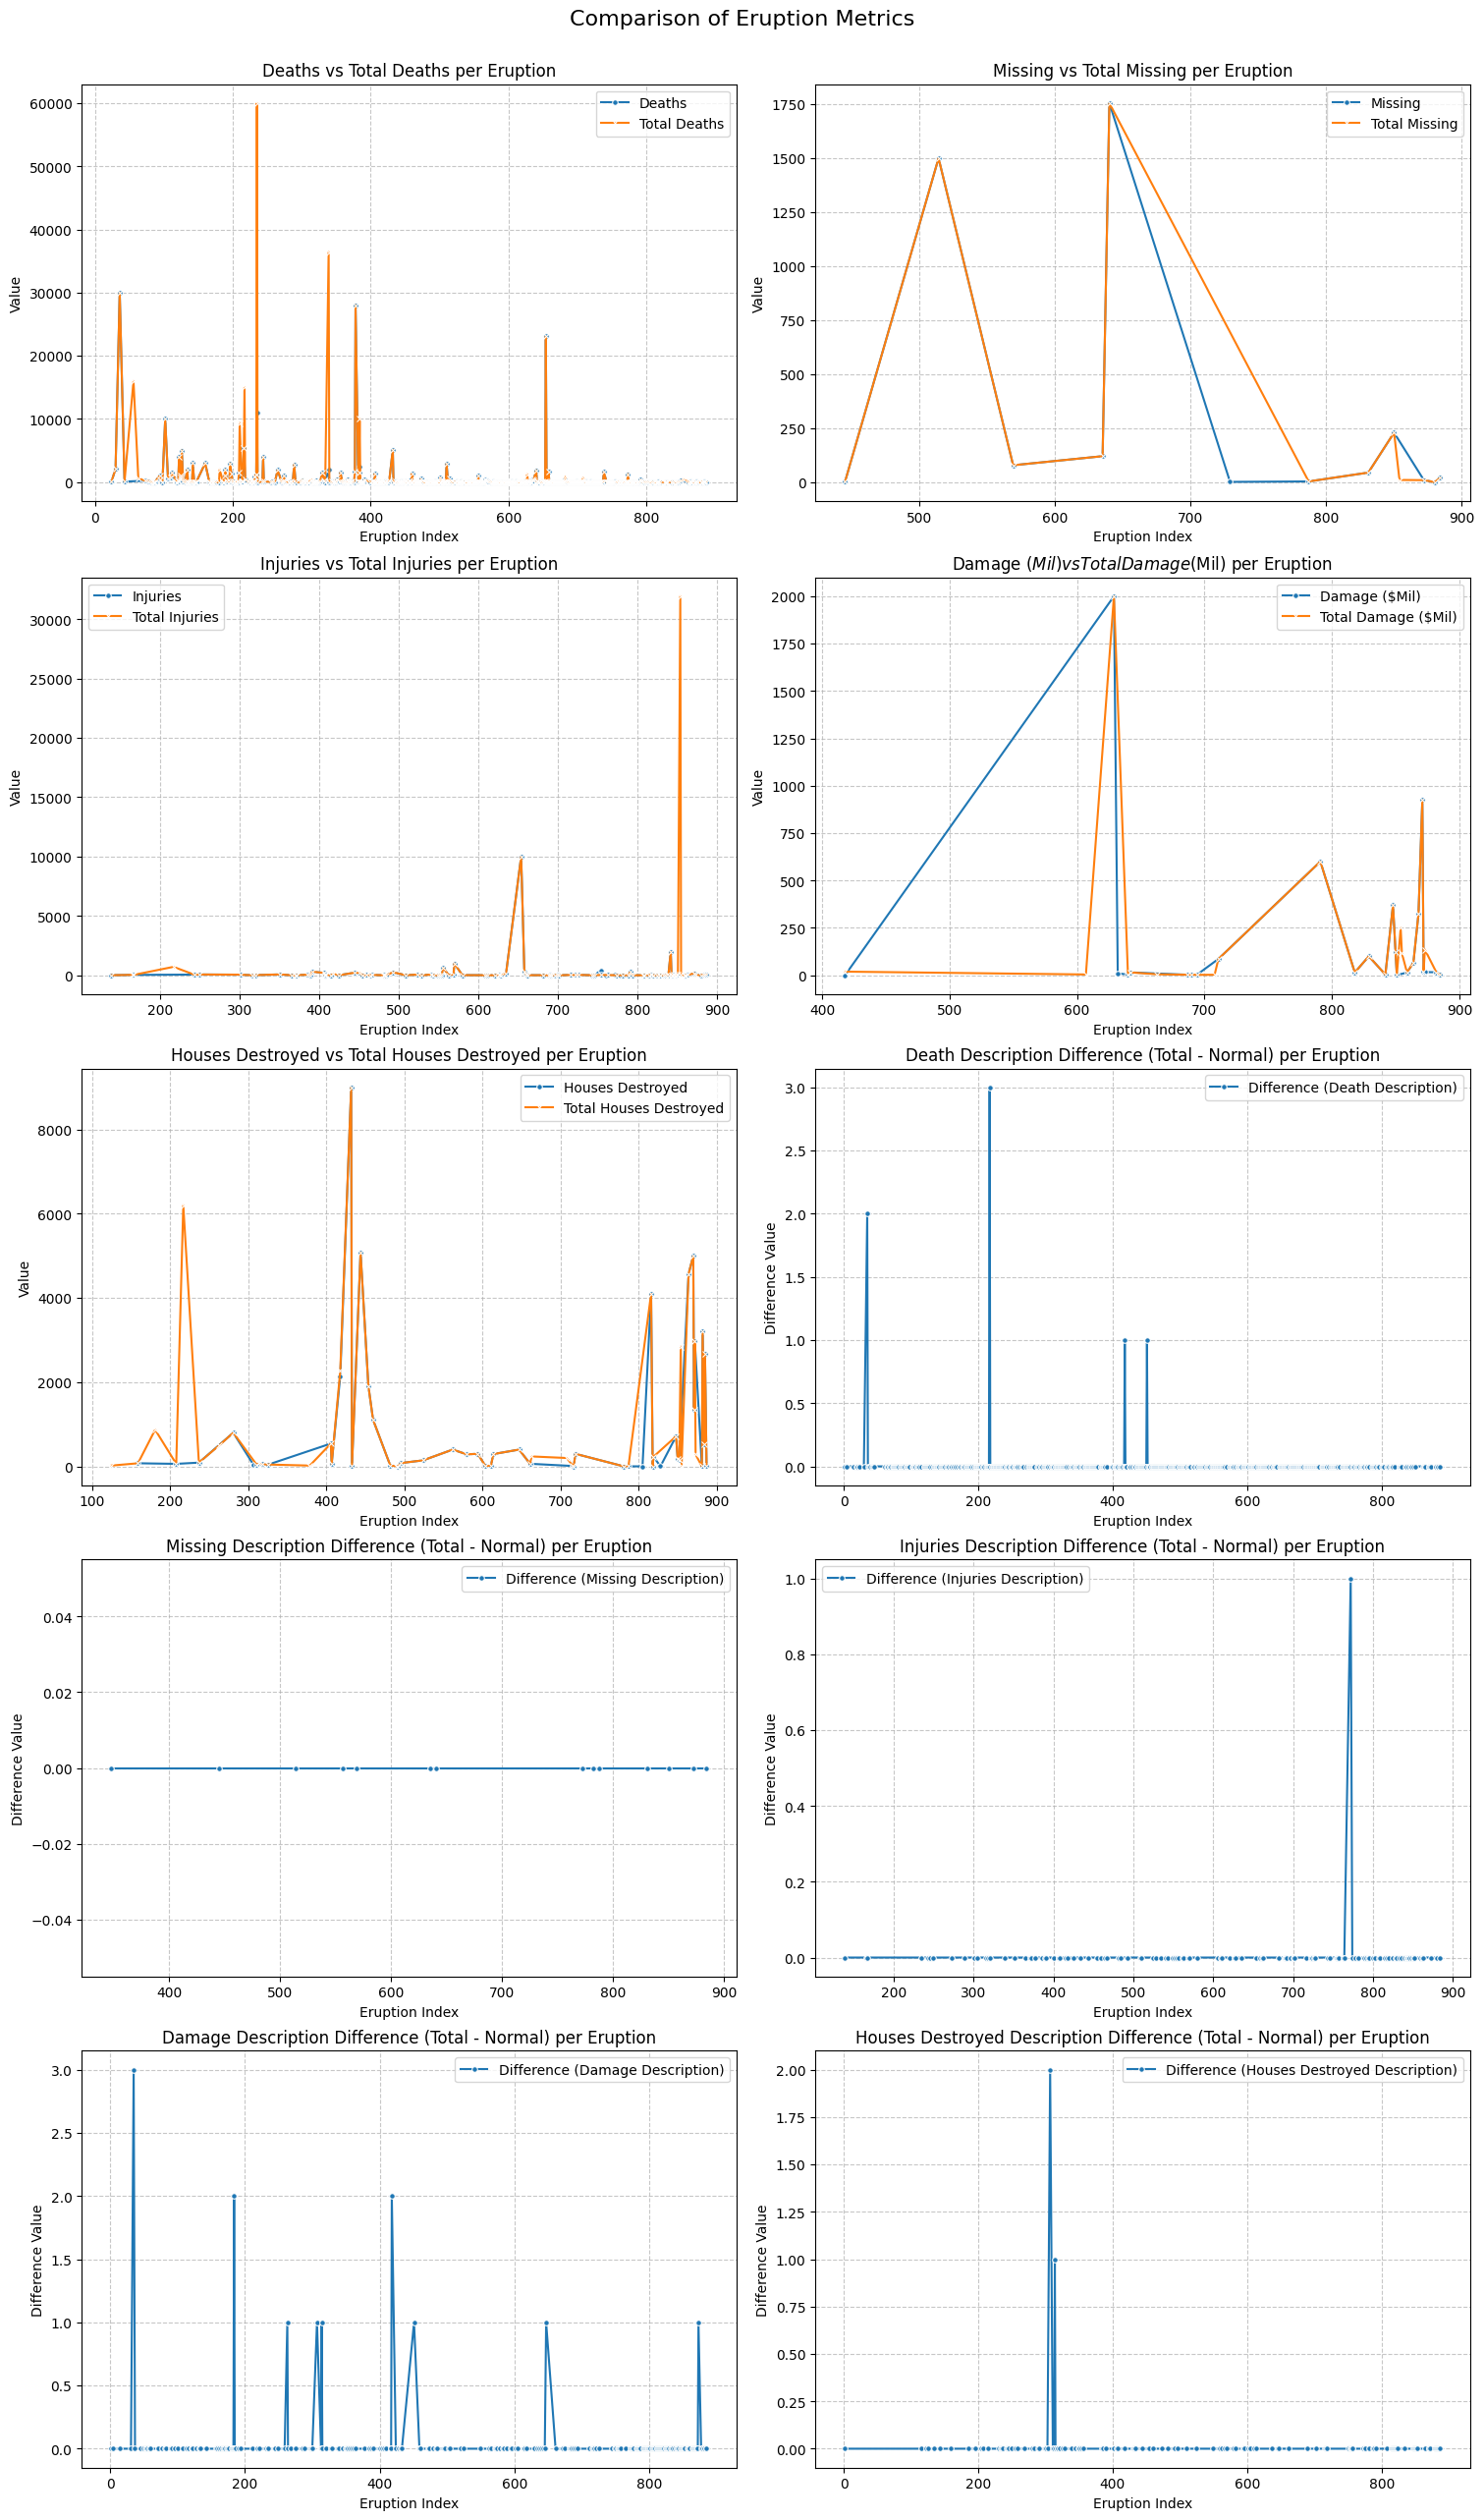

In [613]:
def plot_eruption_comparison_curves(df: pd.DataFrame):
    """
    Draws curve graphs comparing pairs of related metrics per eruption.

    For certain pairs (e.g., 'Deaths' vs 'Total Deaths'), two lines
    are plotted on the same subplot against the DataFrame's index (representing eruptions).
    For 'Description' related pairs, the difference ('Total' - 'Normal') is plotted.

    Args:
        df (pd.DataFrame): The DataFrame containing eruption data.
                          It must contain the columns specified in the `comparison_pairs`.
    """
    comparison_pairs = [
        ('Deaths', 'Total Deaths'),
        ('Missing', 'Total Missing'),
        ('Injuries', 'Total Injuries'),
        ('Damage ($Mil)', 'Total Damage ($Mil)'),
        ('Houses Destroyed', 'Total Houses Destroyed'),
        ('Death Description', 'Total Death Description'),
        ('Missing Description', 'Total Missing Description'),
        ('Injuries Description', 'Total Injuries Description'),
        ('Damage Description', 'Total Damage Description'),
        ('Houses Destroyed Description', 'Total Houses Destroyed Description')
    ]

    # Determine the number of subplots needed
    num_pairs = len(comparison_pairs)
    # Arrange subplots in a grid, e.g., 2 columns
    n_cols = 2
    n_rows = (num_pairs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), layout='constrained')
    axes = axes.flatten() # Flatten in case of single row/column or to easily iterate

    for i, (col1, col2) in enumerate(comparison_pairs):
        ax = axes[i]
        
        # Ensure columns exist before plotting
        if col1 in df.columns and col2 in df.columns:
            if "Description" in col1 and "Description" in col2:
                # For Description columns, plot the difference (Total - Normal)
                diff_label = f'Difference ({col2.replace("Total ", "")})'
                sns.lineplot(data=df, x=df.index, y=df[col2] - df[col1], label=diff_label, ax=ax, marker='o', markersize=4)
                ax.set_title(f'{col2.replace("Total ", "")} Difference (Total - Normal) per Eruption')
                ax.set_ylabel('Difference Value')
            else:
                # For other columns, plot both values
                sns.lineplot(data=df, x=df.index, y=col1, label=col1, ax=ax, marker='o', markersize=4)
                sns.lineplot(data=df, x=df.index, y=col2, label=col2, ax=ax, marker='x', markersize=4)
                ax.set_title(f'{col1} vs {col2} per Eruption')
                ax.set_ylabel('Value')
            
            ax.set_xlabel('Eruption Index')
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.7)
        else:
            ax.set_title(f'Data Missing for {col1} or {col2}')
            ax.text(0.5, 0.5, 'Columns not found in DataFrame', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=12, color='red')
            ax.set_xticks([])
            ax.set_yticks([])

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Comparison of Eruption Metrics', fontsize=16, y=1.02)
    plt.show()

plot_eruption_comparison_curves(df_agent_divided)


Comparing the 'Total' and 'Normal' columns we see that they are largely the same, with some value not overlapping and some anomalies (like total being inferior to normal). To analyse the data more easily we will consolidate all of these column pairs into the normal column (Total Deaths and Deaths will be consolidated in the Death column while Total Death will be dropped). To consolidate and remove anomalies we will take the maximum between the two columns for each eruption.

In [614]:
def process_total_normal_data(df):
    """
    Processes volcano data to consolidate 'Total' and 'Normal' columns for easier analysis.

    Comparing 'Total' and 'Normal' columns (e.g., 'Total Deaths' and 'Deaths'), anomalies
    can be observed where values might not overlap or 'Total' values are sometimes
    less than their 'Normal' counterparts. To address these inconsistencies and
    streamline analysis, this function consolidates these pairs into the 'Normal'
    column by taking the maximum value between the two for each eruption.
    The 'Total' columns are then dropped.

    Args:
        df (pd.DataFrame): The input DataFrame containing volcano data.

    Returns:
        pd.DataFrame: The processed DataFrame with consolidated and cleaned columns.
    """
    column_pairs = [
        ('Deaths', 'Total Deaths'),
        ('Missing', 'Total Missing'),
        ('Injuries', 'Total Injuries'),
        ('Damage ($Mil)', 'Total Damage ($Mil)'),
        ('Houses Destroyed', 'Total Houses Destroyed'),
        ('Death Description', 'Total Death Description'),
        ('Missing Description', 'Total Missing Description'),
        ('Injuries Description', 'Total Injuries Description'),
        ('Damage Description', 'Total Damage Description'),
        ('Houses Destroyed Description', 'Total Houses Destroyed Description')
    ]

    for col_name, total_col_name in column_pairs:
        # Calculate the maximum between the two columns for each row
        df[col_name] = df[[col_name, total_col_name]].max(axis=1)

    # Drop the 'Total' columns
    columns_to_drop = [pair[1] for pair in column_pairs]
    df = df.drop(columns=columns_to_drop)

    return df

df_processed = process_total_normal_data(df_agent_divided)



In [615]:
def check_description_values(df):
    """
    Checks the unique values of all columns ending with 'Description'.
    Input: df (pd.DataFrame)
    Output: None
    """
    print("Inspecting Unique Values in Description Columns")
    
    # Filter columns that end with 'Description'
    description_cols = [col for col in df.columns if col.endswith('Description')]
    
    if not description_cols:
        print("No columns ending with 'Description' found.")
        return

    for col in description_cols:
        # Get unique values, dropping NaNs to see the codes clearly
        unique_vals = sorted(df[col].dropna().unique())
        print(f"Unique values in '{col}': {unique_vals}")

# Run the function
check_description_values(df_agent_divided)

Inspecting Unique Values in Description Columns
Unique values in 'Death Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Missing Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Injuries Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Damage Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Houses Destroyed Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Total Death Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Total Missing Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Total Injuries Description': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Unique values in 'Total Damage Description': [np.float64

Looking at the description columns we see that they represent ordinal scales like we thought. This can be redundant with the columns that represent the actual number of fatalities, injuries, missing persons... But maybe they are interesting since we may lack precise data for some of the older eruptions.



In [616]:
def analyze_information_loss(df):
    """
    Analyzes potential information loss for all Description columns.
    It counts rows where the Quantitative value is Missing (NaN) 
    but the Qualitative Description exists (Not NaN), and vice-versa.
    
    Input: df (pd.DataFrame)
    Output: Prints a summary table
    """
    
    # 1. Define the pairs: (Quantitative Column, Description Column)
    pairs = [
        ('Deaths', 'Death Description'),
        ('Missing', 'Missing Description'),
        ('Injuries', 'Injuries Description'),
        ('Damage ($Mil)', 'Damage Description'),
        ('Houses Destroyed', 'Houses Destroyed Description'),
        ('Total Deaths', 'Total Death Description'),
        ('Total Missing', 'Total Missing Description'),
        ('Total Injuries', 'Total Injuries Description'),
        ('Total Damage ($Mil)', 'Total Damage Description'),
        ('Total Houses Destroyed', 'Total Houses Destroyed Description')
    ]
    
    print(f"{'Quantitative Column':<25} | {'Missing Qty':<12} | {'Description Col':<30} | {'Hidden Data (Loss)':<20} | {'Missing Desc'}")
    print("-" * 120)
    
    for qty_col, desc_col in pairs:
        # Verify columns exist in dataframe to avoid errors
        if qty_col not in df.columns or desc_col not in df.columns:
            print(f"{qty_col:<25} | {'N/A':<12} | {desc_col:<30} | {'Column Not Found':<20} | {'Column Not Found'}")
            continue
            
        # Count total missing quantitative values
        missing_qty = df[qty_col].isna().sum()
        
        # Count "Hidden Data": Rows where Qty is NaN AND Desc is NOT NaN
        # These are the events you lose if you simply drop the description column.
        hidden_data_loss_count = df[df[qty_col].isna() & df[desc_col].notna()].shape[0]
        
        # Count "Missing Description": Rows where Qty is NOT NaN AND Desc is NaN
        # These are events with a quantitative value but no descriptive context.
        missing_desc_count = df[df[qty_col].notna() & df[desc_col].isna()].shape[0]
        
        print(f"{qty_col:<25} | {missing_qty:<12} | {desc_col:<30} | {hidden_data_loss_count:<20} | {missing_desc_count}")

analyze_information_loss(df_agent_divided)


Quantitative Column       | Missing Qty  | Description Col                | Hidden Data (Loss)   | Missing Desc
------------------------------------------------------------------------------------------------------------------------
Deaths                    | 421          | Death Description              | 131                  | 0
Missing                   | 875          | Missing Description            | 4                    | 2
Injuries                  | 780          | Injuries Description           | 27                   | 0
Damage ($Mil)             | 859          | Damage Description             | 252                  | 0
Houses Destroyed          | 826          | Houses Destroyed Description   | 95                   | 0
Total Deaths              | 423          | Total Death Description        | 131                  | 0
Total Missing             | 876          | Total Missing Description      | 4                    | 1
Total Injuries            | 784          | Total Injuries De

Looking at this result we can therefore see that dropping the description columns is not a good idea. We therefore have to find a way to understand this ordinal orders. To do this we will visualise the distribution of the description columns compared to the numerical values they represent in rows where we have both.

In [617]:
def analyze_all_description_pairs(df):
    """
    Loops through multiple metric/description pairs to verify if they all follow 
    the ordinal scale pattern (1-4).
    """
    # We want to investigate the pairs as followed :  (Metric Column, Description Column)
    pairs_to_check = [
        ('Deaths', 'Death Description'),
        ('Missing', 'Missing Description'),
        ('Injuries', 'Injuries Description'),
        ('Damage ($Mil)', 'Damage Description'),
        ('Houses Destroyed', 'Houses Destroyed Description'),
        ('Total Deaths', 'Total Death Description'),
        ('Total Missing', 'Total Missing Description'),
        ('Total Injuries', 'Total Injuries Description'),
        ('Total Damage ($Mil)', 'Total Damage Description'),
        ('Total Houses Destroyed', 'Total Houses Destroyed Description')
    ]

    for metric_col, desc_col in pairs_to_check:
        df_filtered = df.dropna(subset=[metric_col, desc_col])
        # Check if columns exist in the dataframe before proceeding
        if metric_col in df_filtered.columns and desc_col in df_filtered.columns:
            print(f"Analysis: {metric_col}  vs.  {desc_col}")

            
            #Statistical Check
            # Group by the description (1, 2, 3, 4) and see the range of the actual numbers
            stats = df.groupby(desc_col)[metric_col].agg(
                Count='count', 
                Min='min', 
                Median='median', 
                Max='max',
                Mean='mean'
            )
            print(stats)
            
            # Filter data for plotting
            plot_df = df.dropna(subset=[metric_col, desc_col]).copy()
            plot_df['Category'] = plot_df[desc_col].astype(str) # Convert to string for categorical plotting
            
            fig = px.box(df_filtered, 
                        x=desc_col, 
                        y=metric_col, 
                        points="all", 
                        title=f"Distribution of {metric_col} by Category (Log Scale)",
                        log_y=True,
                        labels={desc_col: 'Category Description', metric_col: f'{metric_col} (Log Scale)'},
                        color=desc_col
                        )
            fig.show()
            
        else:
            print(f"Skipping pair {metric_col}/{desc_col}: Columns not found.")


analyze_all_description_pairs(df_agent_divided)

Analysis: Deaths  vs.  Death Description
                   Count     Min  Median      Max         Mean
Death Description                                             
1.0                  344     1.0     2.0    103.0     7.546512
2.0                   27    54.0    68.0    120.0    71.555556
3.0                   52   106.0   220.5   1000.0   331.423077
4.0                   44  1001.0  2000.0  60000.0  7097.090909


Analysis: Missing  vs.  Missing Description
                     Count     Min  Median     Max         Mean
Missing Description                                            
1.0                      6     2.0     9.5    44.0    14.666667
2.0                      1    78.0    78.0    78.0    78.000000
3.0                      2   120.0   174.5   229.0   174.500000
4.0                      2  1500.0  1627.5  1755.0  1627.500000


Analysis: Injuries  vs.  Injuries Description
                      Count     Min   Median      Max          Mean
Injuries Description                                               
1.0                      82     1.0      5.5     50.0     11.621951
2.0                       9    13.0     64.0     86.0     59.000000
3.0                      14   112.0    263.5   1000.0    349.785714
4.0                       3  1972.0  10000.0  31943.0  14638.333333


Analysis: Damage ($Mil)  vs.  Damage Description
                    Count   Min   Median     Max     Mean
Damage Description                                       
1.0                     1   1.0    1.000     1.0    1.000
2.0                     8   2.0    2.750     4.0    2.908
3.0                     8   5.0   14.750    20.0   14.125
4.0                    12  67.0  192.684  2000.0  424.364


Analysis: Houses Destroyed  vs.  Houses Destroyed Description
                              Count     Min  Median     Max         Mean
Houses Destroyed Description                                            
1.0                              22     1.0    10.0    75.0    17.181818
2.0                               6    60.0    69.0    90.0    71.666667
3.0                              20    37.0   296.5   871.0   370.650000
4.0                              14  1109.0  3085.0  9000.0  3734.428571


Analysis: Total Deaths  vs.  Total Death Description
                         Count     Min  Median      Max         Mean
Total Death Description                                             
1.0                        342     1.0     2.5    103.0     7.558480
2.0                         27    54.0    68.0    120.0    71.555556
3.0                         52   106.0   220.5   1000.0   331.423077
4.0                         44  1001.0  2000.0  60000.0  7097.090909


Analysis: Total Missing  vs.  Total Missing Description
                           Count     Min  Median     Max         Mean
Total Missing Description                                            
1.0                            6     2.0     9.5    44.0    14.666667
2.0                            1    78.0    78.0    78.0    78.000000
3.0                            2   120.0   174.5   229.0   174.500000
4.0                            2  1500.0  1627.5  1755.0  1627.500000


Analysis: Total Injuries  vs.  Total Injuries Description
                            Count     Min   Median      Max          Mean
Total Injuries Description                                               
1.0                            80     1.0      6.5     50.0     11.837500
2.0                             8    53.0     64.5     86.0     64.750000
3.0                            13   112.0    250.0   1000.0    345.923077
4.0                             3  1972.0  10000.0  31943.0  14638.333333


Analysis: Total Damage ($Mil)  vs.  Total Damage Description
                          Count   Min   Median     Max        Mean
Total Damage Description                                          
1.0                           1   1.0    1.000     1.0    1.000000
2.0                           8   2.0    2.750     4.0    2.908000
3.0                           7   5.0   15.000    20.0   14.714286
4.0                          12  67.0  192.684  2000.0  424.364000


Analysis: Total Houses Destroyed  vs.  Total Houses Destroyed Description
                                    Count     Min  Median     Max         Mean
Total Houses Destroyed Description                                            
1.0                                    20     1.0    12.5    75.0    18.700000
2.0                                     6    60.0    69.0    90.0    71.666667
3.0                                    19   144.0   300.0   871.0   388.210526
4.0                                    14  1109.0  3085.0  9000.0  3734.428571


After analysing the distributions and to get the most out of the data, we will input the median values of the description categories into rows where the numerical values are missing. We chose the median because it is less affected by outliers than other alternatives. This way we will get a better overview of the data especially for older eruptions.

In [618]:
def impute_missing_numericals(df):
    """
    Imputes missing values for ALL quantitative columns (Deaths, Injuries, Damage, etc.)
    based on their corresponding Description columns using the Median strategy.
    
    For each category (1, 2, 3, 4) in a Description column, we calculate the 
    median of the non-missing values in the corresponding Quantitative column, 
    and use that to fill the missing values.
    input: df (pandas.DataFrame)
    output: df_imputed (pandas.DataFrame)
    """

    # Create a copy
    df_imputed = df.copy()
    
    # List of (Quantitative Column, Description Column) pairs
    pairs = [
        ('Deaths', 'Death Description'),
        ('Missing', 'Missing Description'),
        ('Injuries', 'Injuries Description'),
        ('Damage ($Mil)', 'Damage Description'),
        ('Houses Destroyed', 'Houses Destroyed Description'),
        ('Total Deaths', 'Total Death Description'),
        ('Total Missing', 'Total Missing Description'),
        ('Total Injuries', 'Total Injuries Description'),
        ('Total Damage ($Mil)', 'Total Damage Description'),
        ('Total Houses Destroyed', 'Total Houses Destroyed Description')
    ]
    
    print("--- Imputation Report ---")
    
    for qty_col, desc_col in pairs:
        # Check if columns exist in the dataframe to avoid errors
        if qty_col not in df_imputed.columns or desc_col not in df_imputed.columns:
            continue
            
        # 1. Calculate Medians for each description category dynamically
        # This creates a Series like {1.0: 2.0, 2.0: 68.0, ...} specific to this column
        # We assume ordinal scales 1, 2, 3, 4
        median_map = df_imputed.groupby(desc_col)[qty_col].median()
        
        # 2. Identify rows to fill: Qty is NaN AND Desc is NOT NaN
        mask = df_imputed[qty_col].isna() & df_imputed[desc_col].notna()
        
        count_to_fill = mask.sum()
        
        if count_to_fill > 0:
            # 3. Apply Imputation
            # Map the description value to the calculated median
            # Note: If a category has no median (e.g., category 4 exists but has NO numbers), it remains NaN
            df_imputed.loc[mask, qty_col] = df_imputed.loc[mask, desc_col].map(median_map)
            
            print(f"[{qty_col}] Filled {count_to_fill} missing values using calculated medians: {median_map.to_dict()}")
        else:
            print(f"[{qty_col}] No imputable missing values found.")

    return df_imputed

df_imputed = impute_missing_numericals(df_agent_divided)

--- Imputation Report ---
[Deaths] Filled 131 missing values using calculated medians: {1.0: 2.0, 2.0: 68.0, 3.0: 220.5, 4.0: 2000.0}
[Missing] Filled 4 missing values using calculated medians: {1.0: 9.5, 2.0: 78.0, 3.0: 174.5, 4.0: 1627.5}
[Injuries] Filled 27 missing values using calculated medians: {1.0: 5.5, 2.0: 64.0, 3.0: 263.5, 4.0: 10000.0}
[Damage ($Mil)] Filled 252 missing values using calculated medians: {1.0: 1.0, 2.0: 2.75, 3.0: 14.75, 4.0: 192.684}
[Houses Destroyed] Filled 95 missing values using calculated medians: {1.0: 10.0, 2.0: 69.0, 3.0: 296.5, 4.0: 3085.0}
[Total Deaths] Filled 131 missing values using calculated medians: {1.0: 2.5, 2.0: 68.0, 3.0: 220.5, 4.0: 2000.0}
[Total Missing] Filled 4 missing values using calculated medians: {1.0: 9.5, 2.0: 78.0, 3.0: 174.5, 4.0: 1627.5}
[Total Injuries] Filled 30 missing values using calculated medians: {1.0: 6.5, 2.0: 64.5, 3.0: 250.0, 4.0: 10000.0}
[Total Damage ($Mil)] Filled 241 missing values using calculated medians

In [619]:
def impute_description_ordinal_scales(df):
    """
    Imputes missing Description values (Category 1.0, 2.0, 3.0, 4.0) based on the 
    corresponding known Quantitative values.
    
    Logic: 
    1. For each variable (e.g., Deaths), calculate the median value for each known category (1-4).
    2. Determine thresholds (geometric midpoints) between these medians.
    3. Assign missing descriptions (as floats) based on which interval the numeric value falls into.
    """
    df_imputed = df.copy()
    
    pairs = [
        ('Deaths', 'Death Description'),
        ('Missing', 'Missing Description'),
        ('Injuries', 'Injuries Description'),
        ('Damage ($Mil)', 'Damage Description'),
        ('Houses Destroyed', 'Houses Destroyed Description'),
        ('Total Deaths', 'Total Death Description'),
        ('Total Missing', 'Total Missing Description'),
        ('Total Injuries', 'Total Injuries Description'),
        ('Total Damage ($Mil)', 'Total Damage Description'),
        ('Total Houses Destroyed', 'Total Houses Destroyed Description')
    ]
    
    print("--- Description Imputation Report ---")
    
    for qty_col, desc_col in pairs:
        if qty_col not in df_imputed.columns or desc_col not in df_imputed.columns:
            continue
            
        # 1. Get medians for existing categories
        medians = df_imputed.groupby(desc_col)[qty_col].median().sort_index()
        
        if len(medians) < 2:
            print(f"[{desc_col}] Not enough categories to build thresholds. Skipping.")
            continue
            
        # 2. Build Thresholds (Geometric Midpoints)
        thresholds = []
        cats = medians.index.tolist()
        
        for i in range(len(cats) - 1):
            c1 = cats[i]
            c2 = cats[i+1]
            m1 = medians[c1]
            m2 = medians[c2]
            
            if m1 <= 0: m1 = 0.01
            if m2 <= 0: m2 = 0.01
            
            limit = np.sqrt(m1 * m2)
            thresholds.append((limit, c1))
            
        last_cat = cats[-1]
        
        # 3. Apply Imputation
        # Find rows: Qty Is Known (notna) AND Description is Missing (isna)
        mask = df_imputed[qty_col].notna() & df_imputed[desc_col].isna()
        target_indices = df_imputed[mask].index
        
        count = 0
        for idx in target_indices:
            val = df_imputed.at[idx, qty_col]
            assigned_cat = last_cat
            
            for limit, cat in thresholds:
                if val <= limit:
                    assigned_cat = cat
                    break
            
            # Assign as float to match existing columns (1.0, 2.0 etc)
            df_imputed.at[idx, desc_col] = float(assigned_cat)
            count += 1
            
        if count > 0:
            print(f"[{desc_col}] Imputed {count} missing descriptions based on numeric values.")
            # print(f"   Thresholds: {[f'{t[1]}<={t[0]:.1f}' for t in thresholds]}")
    
    return df_imputed

# Apply the function
df_imputed = impute_description_ordinal_scales(df_imputed)

--- Description Imputation Report ---
[Missing Description] Imputed 2 missing descriptions based on numeric values.
[Total Missing Description] Imputed 1 missing descriptions based on numeric values.


In [620]:
analyze_information_loss(df_imputed)

Quantitative Column       | Missing Qty  | Description Col                | Hidden Data (Loss)   | Missing Desc
------------------------------------------------------------------------------------------------------------------------
Deaths                    | 290          | Death Description              | 0                    | 0
Missing                   | 871          | Missing Description            | 0                    | 0
Injuries                  | 753          | Injuries Description           | 0                    | 0
Damage ($Mil)             | 607          | Damage Description             | 0                    | 0
Houses Destroyed          | 731          | Houses Destroyed Description   | 0                    | 0
Total Deaths              | 292          | Total Death Description        | 0                    | 0
Total Missing             | 872          | Total Missing Description      | 0                    | 0
Total Injuries            | 754          | Total Injuries De

In [621]:
def show_missing_data(df):
    """
    Calculates and prints the number of missing values per column.
    Input: df (pd.DataFrame)
    """
    # Requirement: Show the number of missing data points in each column 
    missing_values = df.isnull().sum()
    
    # Filter to show only columns that actually have missing data
    missing_only = missing_values[missing_values > 0]
    
    print("Missing Data Points per Column:")
    if not missing_only.empty:
        print(missing_only)
    else:
        print("No missing values found in the dataset columns.")

show_missing_data(df_agent_divided)

Missing Data Points per Column:
Search Parameters                     887
Year                                    1
Mo                                    132
Dy                                    192
Tsu                                   706
Eq                                    809
Name                                    1
Location                                1
Country                                 1
Latitude                                1
Longitude                               1
Elevation (m)                           1
Type                                    1
VEI                                   183
Deaths                                421
Death Description                     290
Missing                               875
Missing Description                   873
Injuries                              780
Injuries Description                  753
Damage ($Mil)                         859
Damage Description                    607
Houses Destroyed                      826
Ho

Taking a look at the number of missing values per column (NaNs) :
- 'Search Parameters' only has one row (the first one) which is not a NaN, this confirms that this column is useless and an artefact.
- Columns with 1 NaN in reality have none as we already confirmed the first row is an artefact.
- Temporal Precision Issues: While Year is almost complete (only the first row is a NaN), Mo (Month) and Dy (Day) have significantly more missing values (132 and 192 respectively). This is expected as historical volcanic records are often imprecise. We know when an eruption happened by year, but not always the exact date. We cannot rely on creating a precise datetime object for every event as on one hand the negative years are note handled by classic Date Time variables and on the other hand setting the default value for dates with missing months and days to the 1st of January would skew our data. For now the Year column is our most reliable temporal variable.
- Sparse Tsunami and Earthquake Data: The Tsu (Tsunami) and Eq (Earthquake) columns are missing in the vast majority of rows (706 and 809 out of 888). In this context, NaN does not mean "unknown", it almost certainly functions as a Boolean False. It indicates that no tsunami or earthquake was recorded for that event as tsunamis and earthquakes are easily recorded.

We verify if the tsunami column is a boolean column

In [622]:
df_raw['Tsu'].unique()

array([      nan, 3.000e+00, 3.473e+03, 2.100e+01, 3.093e+03, 3.900e+01,
       6.100e+01, 3.102e+03, 2.852e+03, 3.107e+03, 3.112e+03, 2.874e+03,
       5.863e+03, 2.190e+02, 2.220e+02, 3.129e+03, 2.530e+02, 5.754e+03,
       2.690e+02, 2.850e+02, 5.482e+03, 2.930e+02, 3.120e+02, 3.138e+03,
       3.470e+02, 3.141e+03, 3.750e+02, 3.148e+03, 3.150e+03, 3.870e+02,
       4.190e+02, 4.310e+02, 2.853e+03, 5.000e+02, 5.040e+02, 5.250e+02,
       5.280e+02, 5.290e+02, 5.680e+02, 5.770e+02, 3.221e+03, 6.130e+02,
       6.230e+02, 6.310e+02, 6.540e+02, 6.630e+02, 7.060e+02, 7.110e+02,
       7.180e+02, 7.140e+02, 7.300e+02, 7.310e+02, 7.410e+02, 8.090e+02,
       8.210e+02, 8.590e+02, 8.620e+02, 8.690e+02, 9.290e+02, 9.580e+02,
       9.710e+02, 3.451e+03, 1.022e+03, 1.020e+03, 1.068e+03, 1.086e+03,
       1.095e+03, 1.096e+03, 1.109e+03, 5.480e+03, 1.142e+03, 1.143e+03,
       1.144e+03, 1.145e+03, 5.777e+03, 1.175e+03, 1.181e+03, 1.197e+03,
       5.608e+03, 5.629e+03, 1.280e+03, 2.881e+03, 

In [623]:
df_raw['Tsu'].nunique()==df_raw['Tsu'].notna().sum()

np.True_

This is weird, the Tsunami column is filled with incredibly high values. Whatmore there is a different value per Tsunami.

This can be explained by the fact that these values are foreign keys, linking these tsunamis to a tsunami event dataset, this would explain the reason that tsunamis and earthquakes are seperated from the agents column.

We verify that this is also the case for the earthquakes column:

In [624]:
df_raw['Eq'].unique()

array([   nan,  5877.,  7795.,    58.,  7341.,   421.,  9973.,  9788.,
         814.,   920.,  9756.,   942., 10519.,  6879.,  1017.,  1057.,
        8202.,  1129.,  1178.,  1205.,  1304.,  1328.,  1348.,  9532.,
        1515.,  6650.,  6651.,  1787.,  6050.,  1865.,  1867.,  1995.,
        6125., 10184.,  2049.,  6150.,  2125.,  7967.,  2179., 10023.,
        6195.,  6625.,  6198.,  2347.,  6309.,  2595., 10011.,  8158.,
        8391.,  2973.,  2994.,  6877., 10435., 10010.,  3974.,  4116.,
        4227.,  4292.,  4704.,  4876.,  7221.,  4990.,  6652.,  5150.,
        5292.,  5387., 10747.,  6499.,  5568.,  5659., 10555.,  9172.,
       10140., 10332., 10556., 10382., 10383., 10501., 10545., 10744.])

In [625]:
df_raw['Eq'].nunique()==df_raw['Eq'].notna().sum()

np.True_

Since these two columns are foreign keys, we will treat them as boolean values, as in if a row is not null, it is equal to 1, otherwise it is equal to 0.

In [626]:
def process_tsu_eq_columns(df):
    """
    Replaces NaN values with 0 and non-NaN values with 1 in the 'Tsu' and 'Eq' columns.
    Input : df (pandas.DataFrame)
    Output : df_processed (pandas.DataFrame)
    """
    df_processed = df.copy()
    for col in ['Tsu', 'Eq']:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].notna().astype(int)
    return df_processed


In [627]:
def clean_data(df):
    """
    Applies preprocessing: renaming columns, handling types, and filling NaNs.
    Input: df (pd.DataFrame) : The raw dataframe
    Output: df (pd.DataFrame) : The cleaned dataframe
    """

    df = df.drop('Search Parameters', axis=1)
    df = df.iloc[1:]
    df = divide_agents(df)
    df = process_total_normal_data(df)
    df = impute_missing_numericals(df)
    df = impute_description_ordinal_scales(df)
    df = process_tsu_eq_columns(df)
    
    #Rename columns to remove spaces and special characters for easier coding 
    #and for a better understanding
    df = df.rename(columns={
        'Mo': 'Month',
        'Dy': 'Day',
        'Tsu': 'Tsunami',
        'Eq': 'Earthquake',
        'Damage ($Mil)': 'Damage_Millions',
        'Elevation (m)': 'Elevation',
        'Houses Destroyed': 'Houses_Destroyed',
        'Injuries Description': 'Injuries_Description',
        'Death Description': 'Deaths_Description',
        'Damage Description': 'Damage_Description',
        'Missing Description': 'Missing_Description',
        'Houses Destroyed Description': 'Houses_Destroyed_Description'
    })



    return df

df_cleaned = clean_data(df_raw.copy())
print("Data cleaned.")
df_cleaned.head(5)

--- Imputation Report ---
[Deaths] Filled 131 missing values using calculated medians: {1.0: 2.0, 2.0: 68.0, 3.0: 220.5, 4.0: 2000.0}
[Missing] Filled 4 missing values using calculated medians: {1.0: 9.5, 2.0: 78.0, 3.0: 174.5, 4.0: 1627.5}
[Injuries] Filled 27 missing values using calculated medians: {1.0: 5.5, 2.0: 64.0, 3.0: 263.5, 4.0: 10000.0}
[Damage ($Mil)] Filled 252 missing values using calculated medians: {1.0: 1.0, 2.0: 2.75, 3.0: 14.75, 4.0: 192.684}
[Houses Destroyed] Filled 95 missing values using calculated medians: {1.0: 10.0, 2.0: 69.0, 3.0: 296.5, 4.0: 3085.0}
--- Description Imputation Report ---
[Missing Description] Imputed 2 missing descriptions based on numeric values.
Data cleaned.


,Year,Month,Day,Tsunami,Earthquake,Name,Location,Country,Latitude,Longitude,Elevation,Type,VEI,Deaths,Deaths_Description,Missing,Missing_Description,Injuries,Injuries_Description,Damage_Millions,Damage_Description,Houses_Destroyed,Houses_Destroyed_Description,Agent_?,Agent_A,Agent_E,Agent_F,Agent_G,Agent_I,Agent_L,Agent_M,Agent_P,Agent_S,Agent_T,Agent_W,Agent_m
1,-4360.0,NaN,NaN,0,0,Macauley,Kermadec Is,New Zealand,-30.210,-178.475,238.0,Caldera,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0
2,-4350.0,NaN,NaN,0,0,Kikai,Ryukyu Is,Japan,30.793,130.305,704.0,Caldera,7.0,220.5,3.0,NaN,NaN,NaN,NaN,14.75,3.0,296.5,3.0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,-4050.0,NaN,NaN,0,0,Masaya,Nicaragua,Nicaragua,11.985,-86.165,594.0,Caldera,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0
4,-4000.0,NaN,NaN,0,0,Witori,New Britain-SW Pac,Papua New Guinea,-5.576,150.516,724.0,Caldera,6.0,2.0,1.0,NaN,NaN,NaN,NaN,1.00,1.0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,1,0,0
5,-3580.0,NaN,NaN,0,0,Taal,Luzon-Philippines,Philippines,14.002,120.993,311.0,Stratovolcano,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0


Now we want to see if the shape changed after the cleaning.

In [628]:
show_structure(df_cleaned)

Number of Rows: 887
Number of Columns: 36
Data Types:
Year                            float64
Month                           float64
Day                             float64
Tsunami                           int64
Earthquake                        int64
Name                             object
Location                         object
Country                          object
Latitude                        float64
Longitude                       float64
Elevation                       float64
Type                             object
VEI                             float64
Deaths                          float64
Deaths_Description              float64
Missing                         float64
Missing_Description             float64
Injuries                        float64
Injuries_Description            float64
Damage_Millions                 float64
Damage_Description              float64
Houses_Destroyed                float64
Houses_Destroyed_Description    float64
Agent_?                   

In [629]:
show_missing_data(df_cleaned)

Missing Data Points per Column:
Month                           131
Day                             191
VEI                             182
Deaths                          289
Deaths_Description              289
Missing                         870
Missing_Description             870
Injuries                        752
Injuries_Description            752
Damage_Millions                 606
Damage_Description              606
Houses_Destroyed                730
Houses_Destroyed_Description    730
dtype: int64


In [630]:
def show_rankings(df):
    """
    Shows the ranking (correlation) between numerical variables.
    Input: df (pd.DataFrame)
    """
    #We select only numeric columns for correlation analysis
    numeric_df = df.select_dtypes(include=[np.number])

    corr_matrix = numeric_df.corr()

    #Let's see what correlates most strongly with Deaths
    if 'Deaths' in corr_matrix.columns:
        print("Ranking of variables correlated with 'Deaths':")
        print(corr_matrix['Deaths'].sort_values(ascending=False))

show_rankings(df_cleaned)

Ranking of variables correlated with 'Deaths':
Deaths                          1.000000
Missing                         0.758471
Missing_Description             0.723233
Injuries_Description            0.423172
Deaths_Description              0.361159
Injuries                        0.308702
VEI                             0.290583
Damage_Description              0.243078
Agent_W                         0.242436
Houses_Destroyed                0.241334
Houses_Destroyed_Description    0.222332
Tsunami                         0.218267
Agent_I                         0.182680
Agent_P                         0.160556
Agent_A                         0.159744
Damage_Millions                 0.067606
Earthquake                      0.047052
Agent_S                         0.034678
Agent_E                         0.012152
Agent_M                         0.010835
Elevation                       0.004348
Agent_?                        -0.006484
Day                            -0.010614
Agent_F   

## Spatial Analysis

In [631]:
# Function: Build a scatter-based world map showing individual volcano eruptions.
# Input:
#   - df (pd.DataFrame): filtered volcano dataset containing at least
#       ["Latitude", "Longitude", "Type", "Name", "VEI", "Country", "Year", "Deaths"]
# Output:
#   - fig (plotly.graph_objs.Figure): an interactive scatter_geo map (used in Dash)

def get_map_points(df):
    # Copy the dataframe to avoid modifying the original one
    df_map = df_cleaned.copy()

    # Replace missing VEI values with a small default value (0.5)
    # to avoid invisible points on the map
    df_map['VEI_Size'] = df_map['VEI'].fillna(0.5)

    # Create the base geographic scatter plot
    fig = px.scatter_geo(
        df_map,
        lat="Latitude",           # latitude of volcano
        lon="Longitude",          # longitude of volcano
        color="Type",             # volcano morphological category
        size="VEI_Size",          # bubble size based on VEI (explosivity)
        hover_name="Name",        # volcano name in tooltip
        hover_data={              # additional tooltip information
            "Country": True,
            "Year": True,
            "Deaths": True,
            "VEI": True,
            "VEI_Size": False
        },
        title="Global Volcano Distribution (Bubble size = VEI)",
        projection="natural earth", # projection style
        size_max=15,                # maximum bubble size
        template="plotly_dark"      # dark theme to match dashboard
    )

    # Custom color palette: 20 vivid volcanic colors (orange → red → magenta → violet)
    warm_palette = [
   
    "#ffd500",  # deep orange
    "#ff8f00",  # vivid orange
    "#ff3d00",  # bright red-orange
    "#ff1a00",  # pure red-orange
    "#e60000",  # intense red
    "#c51162",  # magenta
    "#ff0055",  # neon pink-red
    "#d81b60",  # pink-magenta
    "#b0003a",  # dark magenta-red
    "#9c004d",  # deep pink-purple
    "#aa00ff",  # neon violet
    "#8e24aa",  # classic violet
    "#7b1fa2",  # deep violet
    "#6a1b9a",  # darker violet
    "#4a148c",  # almost purple-black
    "#7f0000",
    "#b30000",
    "#d50000",
    "#ff1744",
    "#ff4081"
    ]

    n_traces = len(fig.data)   # one trace per volcano Type
    n_colors = len(warm_palette)

    # Assign a distinct color from the palette to each volcano Type
    for i, trace in enumerate(fig.data):
        color = warm_palette[i % n_colors]     # loop through palette if Types > 20
        trace.marker.update(
            color=color,
            line=dict(width=0)                 # remove outline for cleaner look
        )

    # Add geographic features (coastlines, countries, land)
    fig.update_geos(
        showcountries=True,
        showcoastlines=True,
        showland=True,
    )

    # Transparent background to match the dashboard's dark theme
    fig.update_layout(
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        legend=dict(itemdoubleclick=False)
    )

    return fig

get_map_points(df_cleaned)


Looking at the overall distribution of volcanoes on a world map. We can clearly see the 'Ring of Fire' phenomenom dround the Pacific Ocean. Other than that we also see a few volcanoes in central Africa, southern Europe and Iceland.

In [632]:
# This is a dictionary associating all country names from the dataset with their ISO codes. 
# This is done as the option "locationmode='country names'," in the px.choropleth function is deprecated. 
# To ensure stability for future versions of Plotly, we use the ISO codes instead.

COUNTRY_ISO_MAP = {
    'New Zealand': 'NZL',
    'Japan': 'JPN',
    'Nicaragua': 'NIC',
    'Papua New Guinea': 'PNG',
    'Philippines': 'PHL',
    'Italy': 'ITA',
    'United States': 'USA',
    'Chile': 'CHL',
    'Greece': 'GRC',
    'Ecuador': 'ECU',
    'Vanuatu': 'VUT',
    'Yemen': 'YEM',
    'Russia': 'RUS',
    'Indonesia': 'IDN',
    'El Salvador': 'SLV',
    'Saudi Arabia': 'SAU',
    'Iceland': 'ISL',
    'Mexico': 'MEX',
    'North Korea': 'PRK',
    'Ethiopia': 'ETH',
    'Guatemala': 'GTM',
    'Solomon Is.': 'SLB', 
    'Portugal': 'PRT',
    'Colombia': 'COL',
    'Pacific Ocean': None, # No ISO code for Oceans (will be gray/invisible on map)
    'Peru': 'PER',
    'China': 'CHN',
    'Spain': 'ESP',
    'Canada': 'CAN',
    'Tanzania': 'TZA',
    'St. Vincent & the Grenadines': 'VCT',
    'Turkey': 'TUR',
    'St. Kitts & Nevis': 'KNA',
    'Guadeloupe': 'GLP',   
    'Cape Verde': 'CPV',
    'Tonga': 'TON',
    'Taiwan': 'TWN',
    'Eritrea': 'ERI',
    'Comoros': 'COM',
    'Martinique': 'MTQ',   
    'Samoa': 'WSM',
    'Cameroon': 'CMR',
    'Trinidad': 'TTO',     
    'Congo, DRC': 'COD',   
    'Vietnam': 'VNM',
    'Netherlands': 'NLD',
    'Costa Rica': 'CRI',
    'Antarctica': 'ATA',
    'Reunion': 'REU',
    'Montserrat': 'MSR'
}

In [633]:
# Function: Build a choropleth (colored world map) aggregated by country.
# Input:
#   - df (pd.DataFrame): filtered volcano dataset containing at least:
#       ["Country", value_col]
#   - value_col (str): column name used for coloring (e.g., "Count", "Deaths", "Damage_Millions")
#   - title (str): title of the choropleth
#   - color_label (str): label for the colorbar (e.g., "Eruptions", "Deaths", "Damage")
# Output:
#   - fig (plotly.graph_objs.Figure): an interactive choropleth map (used in Dash)

def get_country_choropleth(df, value_col, title, color_label):
    # Aggregate data by country for the selected metric (count, deaths, damage…)
    agg = df.groupby('Country', as_index=False)[value_col].sum()

    # 2. Map Country Names to ISO Codes (The Fix)
    # We create a new column 'iso_alpha' using the dictionary
    agg['iso_alpha'] = agg['Country'].map(COUNTRY_ISO_MAP)
    # Custom continuous volcanic colormap (dark red → orange → magenta → violet)
    # Designed to avoid white/yellow and emphasize bright volcanic tones
    volcano_scale = [
        (0.00, "#000000"),   # very dark base
        (0.05, "#4b0000"),   # deep red
        (0.10, "#7f0000"),   # darker red
        (0.20, "#b00000"),   # intense red
        (0.30, "#d50000"),   # bright red
        (0.40, "#ff1400"),   # red-orange (flashy)
        (0.55, "#ff3d00"),   # bright orange-red
        (0.70, "#ff6d00"),   # orange incandescent
        (0.85, "#ff8500"),   # bright orange
        (0.93, "#d81b60"),   # magenta
        (1.00, "#6a1b9a")    # deep violet
    ]
    # Build the choropleth map
    fig = px.choropleth(
        agg,
        locations='iso_alpha',      # Use the new ISO code column
        locationmode='ISO-3',       # Set mode to ISO-3 (Removes the deprecated warning)
        color=value_col,                # metric used for color intensity
        hover_name='Country',           # tooltip title
        title=title,
        labels={value_col: color_label}, # name of the color axis
        template="plotly_dark",          # dark theme
        color_continuous_scale=volcano_scale,
        projection="natural earth"       # projection style
    )
    # Display country borders, coastlines, and land
    fig.update_geos(
        showcountries=True,
        showcoastlines=True,
        showland=True
    )
    # Transparent background to blend with the dashboard
    fig.update_layout(
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white")
    )

    return fig


In [634]:
dff_map = df_cleaned.copy()
dff_map['Frequency'] = 1
fig1 = get_country_choropleth(dff_map, 'Frequency', "Eruption Frequency by Country", "Eruptions")
fig1.show()

Looking at the eruption frequency by country we notice the same ' Ring of Fire' pehnomenom and overall the same distribution of eruptions as the previous map.

In [635]:
fig = get_country_choropleth(df_cleaned, 'Deaths', "Total Deaths by Country", "Deaths")
fig.show()

Now looking at the number of deaths by countries what we see is interesting, the deaths are not fully determined by the number of eruptions. Russia for example has a lot of eruptions but not many deaths, however this can be explained by the fact that the recorded eruptions in Russia happened primarily in North Eastern Siberia where the population is very low. We also notice that the U.S.A and Japan seem to have overall lower number of deaths than other countries with a similar number of eruptions. This can be explained by the fact that these two countries are wealthier and therefore have better infrastructure to deal with eruptions.

In [636]:
fig = get_country_choropleth(df_cleaned, 'Damage_Millions', "Total Damage by Country", "Damage ($M)")
fig.show()

Conversely looking at the total cost of the damage caused by eruptions, we can see that the United States is overrepresented, even having more damage than Indonesia which was overrepresented in the last 3 maps. This is again a display of economic disparities between these countries, eruptions in the U.S.A. deal more damage as the infrastructure affected is more expensive.

**Spatial Analysis Conclusion:** Eruptions are more likely to occur in regions with high volcanic activity, such as the Pacific Ring of Fire, and within this region they deal more casualties in poorer countries.

## Temporal Analysis of volcanic Eruptions

In [637]:
def build_eruptions_per_year(df):
    """
    # Function: Build a yearly time series of eruptions.
    # Input:
    #   - df (pd.DataFrame): volcano dataset containing at least "Year".
    # Output:
    #   - eruptions_per_year (pd.Series): a time series with index = Year (int) and value = number of eruptions.
    """
    temp = df.dropna(subset=["Year"]).copy()
    temp = temp[temp["Year"] > 0]

    eruptions_per_year = (
        temp
        .groupby("Year")
        .size()
        .sort_index()
    )

    eruptions_per_year.index = eruptions_per_year.index.astype(int)
    eruptions_per_year.name = "eruptions_per_year"

    return eruptions_per_year

In [638]:
def aggregate_eruptions(df, by="year"):
    """
    # Function: Aggregate eruption data by year or by century.
    # Input:
    #   - df (pd.DataFrame): DataFrame containing volcano eruption data, with at least a "Year" column.
    #   - by (str): Specifies the aggregation period. Can be "year" or "century". Defaults to "year".
    # Output:
    #   - grouped (pd.DataFrame): A DataFrame with two columns: "period" (year or century) and "count" (number of eruptions).
    """
    temp = df.dropna(subset=["Year"]).copy()
    temp = temp[temp["Year"] > 0]  # keep AD years only

    if by == "year":
        grouped = (
            temp.groupby("Year")
            .size()
            .reset_index(name="count")
        )
        grouped.rename(columns={"Year": "period"}, inplace=True)
    elif by == "decade":
        temp["decade"] = ((temp["Year"] - 1) // 10 + 1).astype(int)
        grouped = (
            temp.groupby("decade")
            .size()
            .reset_index(name="count")
        )
        grouped.rename(columns={"decade": "period"}, inplace=True)

    elif by == "century":
        # Century numbering: 1..n (e.g. 19 = 1801-1900)
        temp["century"] = ((temp["Year"] - 1) // 100 + 1).astype(int)
        grouped = (
            temp.groupby("century")
            .size()
            .reset_index(name="count")
        )
        grouped.rename(columns={"century": "period"}, inplace=True)

    else:
        raise ValueError("by must be 'year', 'decade' or 'century'")

    return grouped

In [639]:
df_cleaned['Country'].unique()

array(['New Zealand', 'Japan', 'Nicaragua', 'Papua New Guinea',
       'Philippines', 'Italy', 'United States', 'Chile', 'Greece',
       'Ecuador', 'Vanuatu', 'Yemen', 'Russia', 'Indonesia',
       'El Salvador', 'Saudi Arabia', 'Iceland', 'Mexico', 'North Korea',
       'Ethiopia', 'Guatemala', 'Solomon Is.', 'Portugal', 'Colombia',
       'Pacific Ocean', 'Peru', 'China', 'Spain', 'Canada', 'Tanzania',
       'St. Vincent & the Grenadines', 'Turkey', 'St. Kitts & Nevis',
       'Guadeloupe', 'Cape Verde', 'Tonga', 'Taiwan', 'Eritrea',
       'Comoros', 'Martinique', 'Samoa', 'Cameroon', 'Trinidad',
       'Congo, DRC', 'Vietnam', 'Netherlands', 'Costa Rica', 'Antarctica',
       'Reunion', 'Montserrat'], dtype=object)

In [640]:
# Function: Build a time-series figure of eruption frequency over time.
# Input:
#   - df (pd.DataFrame): filtered volcano dataset.
#   - by (str): aggregation level ("year" or "century").
# Output:
#   - fig (plotly.graph_objs.Figure): an interactive time-series plot (used in Dash).
def render_time_series(df, by="year"):

    agg = aggregate_eruptions(df, by=by)

    if by == "year":
        x_label = "Year"
        title = "Number of eruptions per year"
    elif by == "century":
        x_label = "Century"
        title = "Number of eruptions per century"
    else:
        x_label = "Decade"
        title = "Number of eruptions per decade"

    fig = px.line(
        agg,
        x="period",
        y="count",
        markers=True,
        labels={"period": x_label, "count": "Number of eruptions"},
        title=title,
        color_discrete_sequence=['#ff5722']  # orange/red curve
    )

    fig.update_layout(
        height=320,
        autosize=False,
        paper_bgcolor='rgba(0,0,0,0)',   # transparent to fit the dark card
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        xaxis=dict(
            tickmode="auto",
            tickangle=-45
        ),
        margin=dict(l=50, r=20, t=60, b=40)
    )

    fig.update_traces(
        hovertemplate=f"{x_label}: %{{x}}<br>Eruptions: %{{y}}<extra></extra>"
    )

    return fig






In [641]:
fig = render_time_series(df_cleaned, by="year")
fig.show()

In [642]:
fig = render_time_series(df_cleaned, by="decade")
fig.show()

In [643]:
fig = render_time_series(df_cleaned, by="century")
fig.show()

Looking at eruption data over time we see that the number of eruptions has been increasing over time. This indicates that the data is skewed to the right as more data is being collected over time. Indeed we can safely that eruptions are getting more frequent over time. Especially since looking at the data we can see that the number of eruptions seems to be increasing exponentially which is unrealistic to say the least.

For other types of data it is interesting to look at the temporal aspect of the data and try to predict future events. But here if we try to forecast eruptions we will not get a very accurate prediction:

In [644]:
def prepare_prophet_df(eruptions_per_year, min_year=1800):
    """
    Prepares the eruption data for use with the Prophet forecasting model.
    This involves filtering data by a minimum year, renaming columns to 'ds' and 'y'
    as required by Prophet, and converting the 'Year' column to datetime objects.

    Input:
        eruptions_per_year (pd.DataFrame): A DataFrame where the index represents
                                           years and a column contains the count
                                           of eruptions for that year.
        min_year (int, optional): The minimum year from which to include data.
                                  Defaults to 1800.

    Output:
        pd.DataFrame: A DataFrame formatted for Prophet, with 'ds' (datetime)
                      and 'y' (eruption count) columns.
    """
    df_p = eruptions_per_year[eruptions_per_year.index >= min_year].reset_index()
    df_p.columns = ["Year", "y"]
    df_p["ds"] = pd.to_datetime(df_p["Year"], format="%Y")
    return df_p


In [645]:
def forecast_eruptions(df_prophet, n_future_years=20):
    """
    Fit a Prophet model on the historical data and forecast n_future_years ahead.

    Input:
        df_prophet (pd.DataFrame): DataFrame with historical eruption data,
                                   expected to have 'ds' (datetime) and 'y' (numerical) columns.
        n_future_years (int): Number of years to forecast into the future.

    Output:
        pd.DataFrame: A DataFrame containing the forecast, including historical data
                      and future predictions, with columns like 'ds', 'yhat', 'yhat_lower', 'yhat_upper'.
    """
    model = Prophet()
    model.fit(df_prophet)

    # Generate future dates (one point per year)
    future_dates = model.make_future_dataframe(periods=n_future_years, freq="YE")

    # Predict on both historical + future dates
    prediction = model.predict(future_dates)

    return prediction

In [646]:
def make_forecast_figure(df_prophet, prediction):
    """
    Generates a Plotly figure displaying historical yearly volcanic eruption data
    and a Prophet model's forecast of future eruptions.

    Input:
        df_prophet (pd.DataFrame): DataFrame containing historical eruption data,
                                   expected to have 'ds' (datetime) and 'y' (float) columns.
        prediction (pd.DataFrame): DataFrame containing the Prophet model's forecast,
                                   expected to have 'ds' (datetime) and 'yhat' (float) columns.

    Output:
        go.Figure: A Plotly figure object visualizing the historical data and forecast.
    """
    fig = go.Figure()

    # Historical data
    fig.add_trace(go.Scatter(
        x=df_prophet["ds"],
        y=df_prophet["y"],
        mode="lines",
        name="Historical",
        line=dict(color="#ff5722", width=2)
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=prediction["ds"],
        y=prediction["yhat"],
        mode="lines",
        name="Forecast",
        line=dict(color="#ff9800", width=2, dash="dash")  # orange, dashed
    ))

    fig.update_layout(
        title="Forecast of volcanic eruptions per year (Prophet)",
        xaxis_title="Year",
        yaxis_title="Number of eruptions",
        height=320,
        paper_bgcolor='rgba(0,0,0,0)',   # same as other cards
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        margin=dict(l=50, r=20, t=60, b=40),
        legend=dict(bgcolor="rgba(0,0,0,0)")
    )

    return fig

In [647]:
def make_empty_forecast_figure(message):
    """
    Generates a simple, empty Plotly figure to be displayed when
    there is insufficient data to create a meaningful forecast model.
    This is typically used when data filters result in too few data points
    to reliably fit a model like Prophet. The figure includes a title,
    axis labels, and a dark theme.

    Input:
        message (str): The title message to display on the empty figure,
                       explaining why a forecast cannot be generated.

    Output:
        go.Figure: An empty Plotly graph object figure, styled for
                   a dark background with a descriptive title.
    """
    fig = go.Figure()
    fig.update_layout(
        title=message,
        xaxis_title="Time",
        yaxis_title="Number of eruptions",
        height=320,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        margin=dict(l=50, r=20, t=60, b=40)
    )
    return fig

In [648]:
fig = None
try:
    eruptions_per_year = build_eruptions_per_year(df_cleaned)
    df_prophet = prepare_prophet_df(eruptions_per_year, min_year=1800)
    if len(df_prophet) < 10:
        fig = make_empty_forecast_figure("Not enough data since 1800 for forecast")
                 
    prediction = forecast_eruptions(df_prophet, n_future_years=50)
    fig = make_forecast_figure(df_prophet, prediction)
except Exception as e:
    fig = make_empty_forecast_figure(f"Forecast Error: {str(e)}")

fig.show()

12:47:45 - cmdstanpy - INFO - Chain [1] start processing


12:47:45 - cmdstanpy - INFO - Chain [1] done processing


Like expected we only predict a linear growth of eruption (when looking at the data from the past 200 years). But this is on one hand incoherent as the number of eruptions does not increase over time and on the othe the number of eruptions per year varies dramatically year to year.

Therefore:

**Temporal Analysis Conclusion :** Temporal data of eruptions displays only one striking fact, eruptions are unpredictable which is inturn the main reason they are destructive.

In [649]:
def update_layout(fig, title="", x_title="", y_title=""):
    fig.update_layout(
        title=dict(text=title, x=0.5),
        xaxis_title=x_title,
        yaxis_title=y_title,
        template="plotly_dark",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        margin=dict(l=40, r=20, t=60, b=40),
    )
    return fig

In [650]:
# Helper function, no visual test needed directly, but used by others.

In [651]:
def render_temporal_series(df, mode="year"):
    # 3 modes for the dashboard:
    # - 'year'    : time series per year (uses render_time_series)
    # - 'century' : time series per century (uses render_time_series)
    # - 'smooth'  : yearly series + 10-year moving average (Plotly)

    # 1) Yearly series (raw)
    if mode == "year":
        return render_time_series(df, by="year")

    # 2) Century series (raw)
    if mode == "century":
        return render_time_series(df, by="century")

    # 3) Smoothed yearly series (10-year moving average)
    if mode == "smooth":
        per_year = build_eruptions_per_year(df)
        smooth = per_year.rolling(window=10).mean()

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=per_year.index,
            y=per_year.values,
            mode="lines",
            name="Raw yearly data",
            line=dict(width=1, color="#888")   # grey, less dominant
        ))
        fig.add_trace(go.Scatter(
            x=smooth.index,
            y=smooth.values,
            mode="lines",
            name="10-year moving average",
            line=dict(width=3, color="#ff5722")  # main orange/red curve
        ))

        fig.update_layout(
            title="Smoothed eruptions per year (10-year moving average)",
            xaxis_title="Year",
            yaxis_title="Number of eruptions",
            height=320,
            autosize=False,
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            font=dict(color="white"),
            legend=dict(orientation="h", y=-0.2),
            margin=dict(l=50, r=20, t=60, b=40)
        )
        return fig

    # 4) Prophet Forecast
    if mode == "forecast":
        eruptions_per_year = build_eruptions_per_year(df)
        # We need enough data points
        if len(eruptions_per_year) < 20:
            return make_empty_forecast_figure("Not enough data for forecast (need >20 years)")
        
        try:
            df_prophet = prepare_prophet_df(eruptions_per_year, min_year=1800)
            if len(df_prophet) < 10:
                 return make_empty_forecast_figure("Not enough data since 1800 for forecast")
                 
            prediction = forecast_eruptions(df_prophet, n_future_years=50)
            return make_forecast_figure(df_prophet, prediction)
        except Exception as e:
            return make_empty_forecast_figure(f"Forecast Error: {str(e)}")
            
    return go.Figure()

In [652]:
render_temporal_series(df_cleaned, mode='smooth').show()

In [653]:
def get_impact_figure(df):
    top_deadly = df.nlargest(10, 'Deaths').sort_values('Deaths', ascending=True).copy()
    
    def format_label(row):
        y = row['Year']
        name = row['Name']
        month = row.get('Month', 0) # Default to 0 if missing
        
        # Month mapping
        month_map = {
            1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
            7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
        }
        
        try:
            y_int = int(y)
            suffix = "BC" if y_int < 0 else "AD"
            year_str = f"{abs(y_int)} {suffix}"
        except:
            year_str = str(y)
            
        label = f"{name} ({year_str})"
        
        # Add month if valid
        try:
            m_int = int(month)
            if 1 <= m_int <= 12:
                label = f"{name} ({year_str} - {month_map[m_int]})"
        except:
            pass
            
        return label

    # 1. Generate initial labels
    top_deadly['Label'] = top_deadly.apply(format_label, axis=1)
    
    # 2. Ensure Uniqueness (Handle same year, same month/no month collisions)
    final_labels = []
    seen_labels = {}
    
    for label in top_deadly['Label']:
        if label in seen_labels:
            seen_labels[label] += 1
            final_labels.append(f"{label} #{seen_labels[label]}")
        else:
            seen_labels[label] = 1
            final_labels.append(label)
            
    top_deadly['Label'] = final_labels
    
    fig = px.bar(
        top_deadly,
        x="Deaths",
        y="Label",
        orientation='h',
        text="Deaths",
        title="Top 10 Deadliest Eruptions",
        template="plotly_dark"
    )
    fig.update_traces(marker_color='#ff5722', textposition='outside')
    fig.update_layout(
        xaxis_title="Deaths", 
        yaxis_title="",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white")
    )
    return fig

In [654]:
get_impact_figure(df_cleaned).show()

In [655]:
def get_vei_analysis_figure(df, metric='median'):
    # Analysis 1: VEI vs Impact.
    # Allows switching between Median, Mean, Total Deaths, and Total Eruptions.
    
    # Map metric to pandas function and label
    metric_map = {
        'median': ('median', 'Median Deaths'),
        'mean': ('mean', 'Average Deaths'),
        'sum': ('sum', 'Total Deaths'),
        'count': ('count', 'Total Eruptions')
    }
    
    agg_func, label = metric_map.get(metric, ('median', 'Median Deaths'))
    
    # Group and Aggregate
    if metric == 'count':
        # For count, we just count the rows (occurrences of VEI)
        # We name the count column 'Total_Deaths' just to reuse the same y-axis reference in px.bar below
        df_vei = df.groupby('VEI').size().reset_index(name='Deaths') 
    else:
        # We use 'Total_Deaths' as the target variable for death metrics
        df_vei = df.groupby('VEI')['Deaths'].agg(agg_func).reset_index()
    
    fig = px.bar(
        df_vei, x="VEI", y="Deaths",
        title=f"{label} by VEI",
        template="plotly_dark"
    )
    fig.update_traces(marker_color='#ff5722')
    fig.update_layout(
        xaxis_title="Volcanic Explosivity Index (VEI)",
        yaxis_title=label,
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        font=dict(color="white"),
        height=400,
        autosize=False
    )
    return fig

In [656]:
get_vei_analysis_figure(df_cleaned, metric='median').show()

In [657]:
def get_top_countries_by_historical_deaths_figure(df):
    # Analysis 2: Geographic Risk (Top 10 Countries by Deaths)
    df_country = df.groupby('Country')['Deaths'].sum().nlargest(10).sort_values(ascending=True).reset_index()
    fig = px.bar(
        df_country, x="Deaths", y="Country", orientation='h',
        title="Top 10 Countries by Historical Fatalities",
        template="plotly_dark"
    )
    fig.update_traces(marker_color='#ff5722')
    fig.update_layout(
        xaxis_title="Total Confirmed Deaths",
        yaxis_title="",
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        font=dict(color="white")
    )
    return fig

In [658]:
get_top_countries_by_historical_deaths_figure(df_cleaned).show()

In [659]:
def render_top10_deadliest_eruptions(df):
    # Top 10 eruptions by Total Deaths
    if df.empty: return go.Figure()
    dff = df.sort_values("Deaths", ascending=False).head(10)
    fig = px.bar(dff, x="Deaths", y="Name", orientation='h',
                 text="Deaths", color="Deaths", color_continuous_scale="Reds")
    fig.update_traces(textposition='outside')
    fig.update_yaxes(autorange="reversed") # Top 1 at top
    return update_layout(fig, "Top 10 Deadliest Eruptions", "Deaths", "Volcano Name")

In [660]:
render_top10_deadliest_eruptions(df_cleaned).show()

In [661]:
def render_top10_deadliest_volcanoes(df):
    # Group by Volcano Name (some have multiple eruptions)
    if df.empty: return go.Figure()
    dff = df.groupby("Name")["Deaths"].sum().reset_index()
    dff = dff.sort_values("Deaths", ascending=False).head(10)
    fig = px.bar(dff, x="Deaths", y="Name", orientation='h',
                 text="Deaths", color="Deaths", color_continuous_scale="Reds")
    fig.update_traces(textposition='outside')
    fig.update_yaxes(autorange="reversed")
    return update_layout(fig, "Top 10 Deadliest Volcanoes (All Time)", "Total Deaths", "Volcano Name")

In [662]:
render_top10_deadliest_volcanoes(df_cleaned).show()

In [663]:
def render_top10_deadliest_countries(df):
    if df.empty: return go.Figure()
    dff = df.groupby("Country")["Deaths"].sum().reset_index()
    dff = dff.sort_values("Deaths", ascending=False).head(10)
    fig = px.bar(dff, x="Deaths", y="Country", orientation='h',
                 text="Deaths", color="Deaths", color_continuous_scale="Reds")
    fig.update_traces(textposition='outside')
    fig.update_yaxes(autorange="reversed")
    return update_layout(fig, "Top 10 Deadliest Countries", "Total Deaths", "Country")

In [664]:
render_top10_deadliest_countries(df_cleaned).show()

In [665]:
def render_deaths_over_time(df):
    """
    Bar chart of deaths aggregated by Century.
    """
    if df.empty: return go.Figure()

    # 1. Create Century Column (e.g., 1815 -> 1800)
    # We use .copy() to avoid SettingWithCopy warnings on the original dataframe
    dff = df.copy()
    dff['Century'] = (dff['Year'] // 100) * 100

    # 2. Smart Aggregation
    # We sort by deaths first so 'first' captures the deadliest event
    dff_sorted = dff.sort_values('Deaths', ascending=False)

    stats = dff_sorted.groupby("Century").agg(
        Total_Deaths=('Deaths', 'sum'),
        Event_Count=('Name', 'count')
    ).reset_index()

    # Filter to show only relevant history (e.g., from 1000 AD onwards) or keep all
    # stats = stats[stats['Century'] >= 1000] # Optional: Uncomment to filter ancient history
    stats = stats[stats['Total_Deaths'] > 0] # Remove empty centuries

    # 3. Create Bar Chart
    fig = px.bar(
        stats,
        x="Century",
        y="Total_Deaths",
        color="Total_Deaths",
        color_continuous_scale="Reds",
        # Add context to the tooltip
        hover_data={
            'Century': False,
            'Total_Deaths': ':,',
            'Event_Count': True
        },
        labels={'Total_Deaths': 'Fatalities', 'Century': 'Century (Start Year)'},
        title="<b>Volcanic Fatalities by Century</b>"
    )

    # 4. Layout
    fig.update_layout(
        template="plotly_dark",
        xaxis=dict(title="Century", tickformat="d"), # 'd' ensures 1900, not 1.9k
        yaxis=dict(title="Total Deaths"),
        coloraxis_showscale=False,
        hovermode="x unified"
    )

    # Optional: Annotation for the deadliest century (1800s)
    if not stats.empty:
        top_century = stats.loc[stats['Total_Deaths'].idxmax()]
        fig.add_annotation(
            x=top_century['Century'],
            y=top_century['Total_Deaths'],
            text=f"<b>Peak: {top_century['Total_Deaths']:,} deaths in {top_century['Century']}s</b>",
            showarrow=True,
            arrowhead=1,
            ay=-40
        )

    return fig

In [666]:
render_deaths_over_time(df_cleaned).show()

In [667]:
def render_top10_deadliest_regions(df):

    if df.empty: return go.Figure()
    dff = df.groupby("Location")["Deaths"].sum().reset_index()
    dff = dff.sort_values("Deaths", ascending=False).head(10)
    fig = px.bar(dff, x="Deaths", y="Location", orientation='h',
                 text="Deaths", color="Deaths", color_continuous_scale="Reds")
    fig.update_traces(textposition='outside')
    fig.update_yaxes(autorange="reversed")
    return update_layout(fig, "Top 10 Deadliest Regions", "Total Deaths", "Region")

In [668]:
render_top10_deadliest_regions(df_cleaned).show()

In [669]:
def render_region_volcano_sunburst(df):
    """
    Hierarchy: Country -> Region (Location) -> Name
    Adapted to reconstruct agent strings from binary columns.
    """
    if df.empty: 
        return go.Figure()

    # 1. Filter for deadly events only
    dff = df[df["Deaths"] > 0].copy()
    
    if dff.empty: 
        return go.Figure()

    # 2. Reconstruct the 'Agent' string from binary columns for the tooltip
    # Find all columns starting with 'Agent_'
    agent_cols = [col for col in dff.columns if col.startswith('Agent_')]
    
    def get_active_agents(row):
        active_agents = []
        for col in agent_cols:
            if row[col] == 1:
                # Convert 'Agent_P' -> 'P'
                agent_code = col.replace('Agent_', '')
                active_agents.append(agent_code)
        return ", ".join(active_agents) if active_agents else "Unknown"

    dff['Active_Agents'] = dff.apply(get_active_agents, axis=1)

    # 3. Generate Sunburst
    # Note: Using 'Location' instead of 'Locations' based on standard file schema
    fig = px.sunburst(
        dff, 
        path=['Country', 'Location', 'Name'], 
        values='Deaths',
        color='Deaths', 
        color_continuous_scale='Reds',
        # Use the newly created string column for the hover data
        hover_data={'Type': True, 'Active_Agents': True, 'Deaths': ':,', 'Location': False, 'Country': False},
        title="Regional Hierarchy of Fatalities"
    )
    
    # Clean up the hover label formatting
    fig.update_traces(
        hovertemplate="<b>%{label}</b><br>Deaths: %{value:,.0f}<br>Type: %{customdata[0]}<br>Agents: %{customdata[1]}"
    )

    return update_layout(fig, "Regional Hierarchy of Fatalities")

In [670]:
render_region_volcano_sunburst(df_cleaned).show()

In [671]:
def render_deadliest_volcanoes_treemap(df):
    if df.empty: return go.Figure()
    dff = df[df["Deaths"] > 0].copy()
    if dff.empty: return go.Figure()
    fig = px.treemap(dff, path=['Country', 'Type', 'Name'], values='Deaths',
                     color='Deaths', color_continuous_scale='Reds')
    return update_layout(fig, "Treemap of Fatalities by Country & Type")

In [672]:
render_deadliest_volcanoes_treemap(df_cleaned).show()

In [673]:
def render_deadliest_volcanoes_donut(df):
    # Share of deaths by Volcano Type
    if df.empty: return go.Figure()
    dff = df.groupby("Type")["Deaths"].sum().reset_index()
    
    # Group small percentages (< 1%) into 'Other'
    total_deaths = dff["Deaths"].sum()
    if total_deaths > 0:
        mask = dff["Deaths"] / total_deaths >= 0.01
        large = dff[mask].copy()
        small_sum = dff[~mask]["Deaths"].sum()
        
        if small_sum > 0:
            other_df = pd.DataFrame([{'Type': 'Other', 'Deaths': small_sum}])
            dff = pd.concat([large, other_df], ignore_index=True)
        else:
            dff = large
        
    fig = px.pie(dff, values='Deaths', names='Type', hole=0.4,
                 color_discrete_sequence=px.colors.sequential.Reds_r)
    return update_layout(fig, "Share of Fatalities by Volcano Type")

In [674]:
render_deadliest_volcanoes_donut(df_cleaned).show()

In [675]:
def render_deaths_vs_injuries_scatter(df):
    if df.empty: return go.Figure()
    fig = px.scatter(df, x="Injuries", y="Deaths", color="Type",
                     hover_data=["Name", "Year", "Country"], log_x=True, log_y=True)
    return update_layout(fig, "Deaths vs Injuries (Log Scale)", "Injuries", "Deaths")

In [676]:
render_deaths_vs_injuries_scatter(df_cleaned).show()

In [677]:
def render_deaths_vs_injuries_bubble(df):
    # Size = VEI or Damage? Let's use VEI
    if df.empty: return go.Figure()
    dff = df.copy()
    dff['VEI'] = dff['VEI'].fillna(0)
    # Ensure VEI is positive for size
    dff['VEI_Size'] = dff['VEI'].apply(lambda x: max(0.1, x))
    fig = px.scatter(dff, x="Injuries", y="Deaths", size="VEI_Size", color="Type",
                     hover_data=["Name", "Year", "VEI"], log_x=True, log_y=True)
    return update_layout(fig, "Deaths vs Injuries (Size = VEI)", "Injuries", "Deaths")

In [678]:
render_deaths_vs_injuries_bubble(df_cleaned).show()

In [679]:
def render_top10_injury_ratio(df):
    # Ratio = Injuries / Deaths (for events with > 0 deaths)
    if df.empty: return go.Figure()
    dff = df[(df["Deaths"] > 10) & (df["Injuries"] > 0)].copy()
    if dff.empty: return go.Figure()
    dff["Injury_Death_Ratio"] = dff["Injuries"] / dff["Deaths"]
    dff = dff.sort_values("Injury_Death_Ratio", ascending=False).head(10)
    fig = px.bar(dff, x="Injury_Death_Ratio", y="Name", orientation='h',
                 text="Injury_Death_Ratio", color="Injury_Death_Ratio", color_continuous_scale="Viridis")
    fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
    fig.update_yaxes(autorange="reversed")
    return update_layout(fig, "Top 10 Events by Injury/Death Ratio (>10 Deaths)", "Ratio (Injuries/Deaths)", "Volcano")

In [680]:
render_top10_injury_ratio(df_cleaned).show()

In [681]:
def render_injury_ratio_scatter(df):
    if df.empty: return go.Figure()
    dff = df[(df["Deaths"] > 0) & (df["Injuries"] > 0)].copy()
    if dff.empty: return go.Figure()
    dff["Injury_Death_Ratio"] = dff["Injuries"] / dff["Deaths"]
    fig = px.scatter(dff, x="Year", y="Injury_Death_Ratio", color="Type",
                     hover_data=["Name", "Country"], log_y=True)
    return update_layout(fig, "Injury/Death Ratio Over Time", "Year", "Ratio (Log)")

In [682]:
render_injury_ratio_scatter(df_cleaned).show()

In [683]:
def render_death_boxplot(df):
    if df.empty: return go.Figure()
    dff = df[df["Deaths"] > 0]
    fig = px.box(dff, y="Deaths", log_y=True, points="all")
    return update_layout(fig, "Distribution of Fatalities (Log Scale)", "", "Deaths")

In [684]:
render_death_boxplot(df_cleaned).show()

In [685]:
def render_death_boxplot_by_type(df):
    if df.empty: return go.Figure()
    dff = df[df["Deaths"] > 0]
    fig = px.box(dff, x="Type", y="Deaths", log_y=True, color="Type")
    return update_layout(fig, "Fatality Distribution by Volcano Type", "Type", "Deaths")

In [686]:
render_death_boxplot_by_type(df_cleaned).show()

In [687]:
def render_pareto_chart(df):
    # Cumulative % of deaths
    if df.empty: return go.Figure()
    dff = df.sort_values("Deaths", ascending=False).reset_index(drop=True)
    dff["Cumulative_Deaths"] = dff["Deaths"].cumsum()
    total_deaths = dff["Deaths"].sum()
    if total_deaths == 0: return go.Figure()
    
    dff["Cumulative_Percentage"] = 100 * dff["Cumulative_Deaths"] / total_deaths
    dff["Rank"] = dff.index + 1
    
    fig = go.Figure()
    fig.add_trace(go.Bar(x=dff["Rank"], y=dff["Deaths"], name="Deaths per Event", marker_color="#ff5722", opacity=0.6))
    fig.add_trace(go.Scatter(x=dff["Rank"], y=dff["Cumulative_Percentage"], name="Cumulative %", yaxis="y2", line=dict(color="white", width=2)))
    
    fig.update_layout(
        title=dict(text="Pareto Chart of Fatalities", x=0.5),
        xaxis_title="Rank (Event)",
        yaxis_title="Deaths",
        yaxis2=dict(title="Cumulative %", overlaying="y", side="right", range=[0, 105], showgrid=False),
        template="plotly_dark",
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        margin=dict(l=40, r=40, t=60, b=40),
        legend=dict(x=0.5, y=0.9, xanchor='center')
    )
    return fig

In [688]:
render_pareto_chart(df_cleaned).show()

In [689]:
def render_loglog_heavytail(df):
    # Rank-Frequency plot (Zipf's law check)
    if df.empty: return go.Figure()
    dff = df[df["Deaths"] > 0].sort_values("Deaths", ascending=False).reset_index(drop=True)
    dff["Rank"] = dff.index + 1
    fig = px.scatter(dff, x="Rank", y="Deaths", log_x=True, log_y=True,
                     title="Log-Log Rank-Size Plot (Heavy Tail Analysis)")
    return update_layout(fig, "Log-Log Rank-Size Plot", "Rank", "Deaths")

In [690]:
render_loglog_heavytail(df_cleaned).show()

In [691]:
def render_correlation_heatmap(df):
    # Select numerical columns
    if df.empty: return go.Figure()
    cols = ["Year", "VEI", "Deaths", "Injuries", "Damage_Millions", "Elevation"]
    # Check which cols exist
    valid_cols = [c for c in cols if c in df.columns]
    if not valid_cols: return go.Figure()
    
    dff = df[valid_cols].corr()
    fig = px.imshow(dff, text_auto=True, color_continuous_scale="RdBu_r", zmin=-1, zmax=1)
    return update_layout(fig, "Correlation Heatmap")

In [692]:
render_correlation_heatmap(df_cleaned).show()

In [693]:
def get_with_and_without_indirect_deaths_by_type_figure(df, metric='mean'):
    # Analysis 3: Secondary Hazards Impact
    # Compares lethality of events with vs. without Tsunami/Earthquake
    
    # Define aggregation logic
    # Check if we are analyzing Agents or Secondary Hazards
    is_agent_analysis = metric.endswith('_agents')
    
    # Clean metric name for mapping
    base_metric = metric.replace('_agents', '')
    
    metric_map = {
        'mean': 'mean',
        'median': 'median',
        'sum': 'sum'
    }
    agg_func = metric_map.get(base_metric, 'mean')
    df_to_use = df.copy()
    
    label_map = {
        'mean': 'Average Deaths',
        'median': 'Median Deaths',
        'sum': 'Deaths (All Eruptions)'
    }
    y_label = label_map.get(base_metric, 'Average Deaths')
    
    res = []

    if is_agent_analysis:
        # Analyze All Agents using new separated columns
        agents_to_analyze = [
            ('P', 'Pyroclastic Flow'),
            ('M', 'Mudflow (Lahar)'),
            ('T', 'Tephra (Ash)'),
            ('W', 'Waves (Tsunami)'),
            ('L', 'Lava Flow'),
            ('G', 'Gas'),
            ('I', 'Indirect'),
            ('A', 'Avalanche'),
            ('F', 'Floods'),
            ('S', 'Seismic'),
            ('E', 'Electrical'),
            ('m', 'Mudflow (Lahar) (m)'), # Assuming Agent_m column exists for this
            ('?', 'Unknown') # Assuming Agent_? column exists for this
        ]
        title_suffix = "(Agents)"
        
        for code, name in agents_to_analyze:
            agent_col_name = f'Agent_{code}'
            if agent_col_name in df_to_use.columns:
                # 'With' means the agent column has a value indicating presence (e.g., 1)
                val_yes = df_to_use[df_to_use[agent_col_name] == 1]['Deaths'].agg(agg_func)
                # 'Without' means the agent column has a value indicating absence (e.g., 0)
                val_no = df_to_use[df_to_use[agent_col_name] == 0]['Deaths'].agg(agg_func)
                
                res.append({'Hazard': name, 'Status': 'With', 'Value': val_yes})
                res.append({'Hazard': name, 'Status': 'Without', 'Value': val_no})
            else:
                # Handle cases where the specific agent column might not exist
                # For example, if 'm' maps to 'Agent_M' and 'Agent_m' doesn't exist
                # Or if '?' maps to 'Agent_Unknown' or similar
                # For now, we'll skip if the column is not found as per the f'Agent_{code}' naming convention.
                # A more robust solution might involve a mapping dictionary for codes to actual column names.
                pass 
            
    else:
        # Analyze Secondary Hazards: Tsunami, Earthquake
        title_suffix = "(Secondary Hazards)"
        
        # Tsunami Analysis
        tsu_yes = df_to_use[df_to_use['Tsunami'].notna()]['Deaths'].agg(agg_func)
        tsu_no = df_to_use[df_to_use['Tsunami'].isna()]['Deaths'].agg(agg_func)
        res.append({'Hazard': 'Tsunami', 'Status': 'With', 'Value': tsu_yes})
        res.append({'Hazard': 'Tsunami', 'Status': 'Without', 'Value': tsu_no})

        # Earthquake Analysis
        eq_yes = df_to_use[df_to_use['Earthquake'].notna()]['Deaths'].agg(agg_func)
        eq_no = df_to_use[df_to_use['Earthquake'].isna()]['Deaths'].agg(agg_func)
        res.append({'Hazard': 'Earthquake', 'Status': 'With', 'Value': eq_yes})
        res.append({'Hazard': 'Earthquake', 'Status': 'Without', 'Value': eq_no})

    df_hazards = pd.DataFrame(res)
    
    fig = px.bar(
        df_hazards, x="Hazard", y="Value", color="Status", barmode="group",
        title=f"Impact Amplification by {title_suffix} ({y_label})",
        template="plotly_dark",
        color_discrete_map={'With': '#ff5722', 'Without': '#757575'}
    )
    fig.update_layout(
        yaxis_title=y_label,
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        font=dict(color="white")
    )
    return fig

In [694]:
get_with_and_without_indirect_deaths_by_type_figure(df_cleaned, metric='mean').show()

In [695]:
def get_volcano_type_figure(df, scale='log', metric='total'):
    # Indicator 4: Volcanic Type vs Impact.
    # Displays Total Deaths or Deaths per Eruption by Volcano Type with selectable scale.

    # 1. Prepare Data
    if df.empty:
        # Use go.Figure for consistent return type
        fig = go.Figure()
        fig.add_annotation(text="No Data Available", x=0.5, y=0.5, showarrow=False, font=dict(color="white"))
        return fig
        
    # Group by Type and calculate sums and counts
    # This creates columns: 'Type', 'Total_Deaths', 'Count'
    df_type = df.groupby('Type').agg(
        Total_Deaths=('Deaths', 'sum'),
        Count=('Name', 'count')
    ).reset_index()
    
    # Calculate Rate
    # FIXED: Use 'Total_Deaths' instead of 'Deaths'
    df_type['Deaths_per_Eruption'] = df_type['Total_Deaths'] / df_type['Count']
    
    # Filter out 0s for the plot to avoid log scale issues or clutter
    # FIXED: Use 'Total_Deaths' instead of 'Deaths'
    df_type = df_type[df_type['Total_Deaths'] > 0] 
    
    if df_type.empty:
        fig = go.Figure()
        fig.add_annotation(text="No Fatalities recorded in selection", x=0.5, y=0.5, showarrow=False, font=dict(color="white"))
        return fig

    # 2. Generate Figure
    is_log = (scale == 'log')
    
    if metric == 'rate':
        x_col = 'Deaths_per_Eruption'
        title_text = "Deaths per Eruption by Volcano Type"
        x_axis_label = f"Deaths per Eruption ({'Log' if is_log else 'Linear'} Scale)"
        hover_template = "Type: %{y}<br>Deaths/Eruption: %{x:.2f}<extra></extra>"
    else:
        x_col = 'Total_Deaths' # FIXED: Changed from 'Deaths' to 'Total_Deaths'
        title_text = "Total Deaths by Volcano Type"
        x_axis_label = f"Total Deaths ({'Log' if is_log else 'Linear'} Scale)"
        hover_template = "Type: %{y}<br>Total Deaths: %{x}<extra></extra>"

    
    # Generate Horizontal Bar Plot
    fig = px.bar(
        df_type.sort_values(x_col, ascending=True), 
        x=x_col, 
        y='Type', 
        orientation='h',
        title=title_text,
        template="plotly_dark",
        log_x=is_log
    )
    fig.update_traces(marker_color='#ff5722', hovertemplate=hover_template)
    fig.update_xaxes(title_text=x_axis_label)
    fig.update_yaxes(title_text="")
    
    # 3. Apply Common Styling (to match dashboard theme)
    fig.update_layout(
        height=400, 
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        font=dict(color="white"),
        margin=dict(l=10, r=10, t=40, b=10),
        autosize=False 
    )
    
    return fig

In [696]:
get_volcano_type_figure(df_cleaned).show()

In [697]:
def volcano_type_vs_hasard_heatmap(df, normalize=False):
    """
    Generates a heatmap of Volcano Types vs Hazards.
    Specifically breaks down Mudflows into: Aggregated, Primary, and Secondary.
    """
    
    # 1. Identify Agent Columns
    agent_cols = [col for col in df.columns if col.startswith('Agent_')]
    
    if not agent_cols:
        fig = go.Figure()
        fig.add_annotation(text="No Hazard Data Available", x=0.5, y=0.5, showarrow=False, font=dict(color="gray", size=20))
        fig.update_layout(template="plotly_dark", xaxis={'visible': False}, yaxis={'visible': False})
        return fig

    # 2. Aggregation: Sum by Type
    agent_type_matrix = df.groupby('Type')[agent_cols].sum()
    
    # 3. Create "Mudflow (Aggregated)" Column
    # We sum Primary (M) and Secondary (m) if they exist
    # Note: We use .get(..., 0) to handle cases where 'm' might be missing entirely in a filtered dataset
    mudflow_agg = agent_type_matrix.get('Agent_M', 0) + agent_type_matrix.get('Agent_m', 0)
    
    # Insert it into the matrix
    agent_type_matrix['Mudflow (Aggregated)'] = mudflow_agg
    
    # 4. Rename and Reorder Columns
    hazard_map = {
        'Agent_P': 'Pyroclastic Flow',
        'Agent_T': 'Tephra (Ash)',
        'Agent_W': 'Waves (Tsunami)',
        'Agent_L': 'Lava Flow',
        'Agent_G': 'Gas',
        'Agent_I': 'Indirect',
        'Agent_A': 'Avalanche',
        'Agent_F': 'Floods',
        'Agent_S': 'Seismic',
        'Agent_E': 'Electrical',
        'Agent_M': 'Mudflow (Primary)',   # Rename M
        'Agent_m': 'Mudflow (Secondary)', # Rename m
        'Agent_?': 'Unknown'
    }
    
    # Rename existing columns
    agent_type_matrix.rename(columns=hazard_map, inplace=True)
    
    # Define desired column order: Put Mudflows first for comparison, then others sorted
    priority_cols = ['Mudflow (Aggregated)', 'Mudflow (Primary)', 'Mudflow (Secondary)']
    other_cols = sorted([c for c in agent_type_matrix.columns if c not in priority_cols])
    
    # Filter to keep only columns that actually exist in this slice
    final_cols = [c for c in priority_cols if c in agent_type_matrix.columns] + other_cols
    agent_type_matrix = agent_type_matrix[final_cols]

    # 5. Normalization Logic
    if normalize:
        total_events_by_type = df['Type'].value_counts()
        total_events_aligned = total_events_by_type.reindex(agent_type_matrix.index)
        agent_type_matrix = agent_type_matrix.div(total_events_aligned, axis=0) * 100
        
        title_text = "Heatmap: Risk Percentage (Hazard Probability per Eruption)"
        color_label = "Probability (%)"
        z_format = ".1f"
    else:
        title_text = "Heatmap: Volcano Types vs. Hazards (Agents)"
        color_label = "Count"
        z_format = "d"

    # 6. Create Plotly Heatmap
    fig = px.imshow(
        agent_type_matrix,
        x=agent_type_matrix.columns,
        y=agent_type_matrix.index,
        color_continuous_scale="Reds",
        title=title_text,
        template="plotly_dark",
        labels=dict(x="Hazard Agent", y="Volcano Type", color=color_label),
        aspect="auto"
    )

    fig.update_traces(hovertemplate="Type: %{y}<br>Agent: %{x}<br>" + color_label + ": %{z:" + z_format + "}<extra></extra>")

    fig.update_layout(
        height=400,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color="white"),
        margin=dict(l=10, r=10, t=40, b=100), # Extra bottom margin for long labels
        autosize=True,
        xaxis_title="", # Title is redundant with labels
        yaxis_title=""
    )
    # Rotate labels for readability
    fig.update_xaxes(side="bottom", tickangle=-45)
    
    return fig

In [698]:
volcano_type_vs_hasard_heatmap(df_cleaned).show()

In [699]:
def get_type_vs_frequency(df):
# 1. Prepare Data
    type_stats = df.groupby('Type').agg({'Name': 'count', 'Deaths': 'mean'}).reset_index()
    type_stats.columns = ['Type', 'Count', 'Avg_Deaths']
    type_stats = type_stats[type_stats['Count'] > 1] # Remove singletons
    type_stats['Avg_Deaths'] = type_stats['Avg_Deaths'].fillna(0)
    
    # 2. Logic: Who gets a label?
    # We label the Top 3 by Frequency AND Top 3 by Deadliness
    top_freq = type_stats.nlargest(3, 'Count')['Type'].tolist()
    top_dead = type_stats.nlargest(3, 'Avg_Deaths')['Type'].tolist()
    # Combine unique labels to show
    labels_to_show = list(set(top_freq + top_dead))

    # Create a new column just for labels (others get empty string)
    type_stats['Label'] = type_stats.apply(
        lambda x: x['Type'] if x['Type'] in labels_to_show else "", axis=1
    )

    # 3. Create Plot
    fig = px.scatter(
        type_stats,
        x='Count',
        y='Avg_Deaths',
        size='Count',                # Bubble size = Frequency
        color='Avg_Deaths',          # Color = Danger
        text='Label',                # Use our smart label column
        color_continuous_scale='Reds',
        log_x=True,
        log_y=True,
        title='<b>Volcano Risk Matrix</b>: Frequency vs. Deadliness',
        labels={'Count': 'Frequency (Log Scale)', 'Avg_Deaths': 'Avg. Deaths (Log Scale)'},
        template="plotly_dark"
    )

    # 4. Add Quadrant Lines (The "Crosshairs")
    # We use x=20 and y=100 as visual thresholds for "High Freq" and "High Death"
    fig.add_hline(y=100, line_dash="dash", line_color="gray", opacity=0.5)
    fig.add_vline(x=20, line_dash="dash", line_color="gray", opacity=0.5)

    # 5. Add Context Annotations (The "Story")
    fig.add_annotation(x=np.log10(500), y=np.log10(2000), text="<b>CRITICAL THREATS</b><br>(Frequent & Deadly)", 
                       showarrow=False, font=dict(color="red", size=10))
    fig.add_annotation(x=np.log10(3), y=np.log10(2000), text="<b>BLACK SWANS</b><br>(Rare but Catastrophic)", 
                       showarrow=False, font=dict(color="orange", size=10))

    # 6. Styling Polish
    fig.update_traces(
        textposition='top center', # Move text above dot
        marker=dict(line=dict(width=1, color='White'), sizemin=5) # Add white ring and min size
    )
    
    fig.update_traces(marker=dict(color='#ff5722', opacity=0.7))
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        showlegend=False,
        coloraxis_showscale=False,
        font=dict(family="Arial", size=12)
    )

    return fig

In [700]:
get_type_vs_frequency(df_cleaned).show()

In [701]:
def get_deaths_vs_damage_figure(df):
    # Scatter plot of Deaths vs Damage.
    # Low availability (~18 events, treat as anecdotal).
    # Filter zeros
    df_plot = df[(df['Deaths'] != 0) & (df['Damage_Millions'] != 0)].copy()
    
    fig = px.scatter(
        df_plot, x="Deaths", y="Damage_Millions",
        title="Deaths vs. Damage ($M)",
        template="plotly_dark",
        hover_name="Name",
        hover_data=["Country", "Year"]
    )
    fig.update_traces(marker=dict(color='#ff5722', opacity=0.7))
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)', 
        plot_bgcolor='rgba(0,0,0,0)', 
        font=dict(color="white")
    )
    return fig

In [702]:
get_deaths_vs_damage_figure(df_cleaned).show()

In [703]:
def get_volcano_type_stats_table(df):
    # Creates a table showing Total Eruptions, Last Eruption Year, 
    # and Mean/Median Time Between Eruptions by Volcano Type.
    if df.empty:
        return dash_table.DataTable()

    # 1. Calculate Intervals
    # Sort by Type and Year to ensure correct diff calculation
    df_sorted = df.sort_values(['Type', 'Year'])
    
    # Calculate difference in years between consecutive eruptions within each Type
    df_sorted['Interval'] = df_sorted.groupby('Type')['Year'].diff()

    # 2. Aggregation
    stats = df_sorted.groupby('Type').agg(
        Total_Eruptions=('Name', 'count'),
        Last_Eruption=('Year', 'max'),
        Mean_Interval=('Interval', 'mean'),
        Median_Interval=('Interval', 'median')
    ).reset_index()

    # 3. Formatting
    # Sort by Total Eruptions descending
    stats = stats.sort_values('Total_Eruptions', ascending=False)

    # Format Last Eruption to be integer
    stats['Last_Eruption'] = stats['Last_Eruption'].fillna(0).astype(int)
    
    # Format Intervals (round to 1 decimal place, fill NaNs with 0 or -)
    stats['Mean_Interval'] = stats['Mean_Interval'].round(1).fillna('-')
    stats['Median_Interval'] = stats['Median_Interval'].round(1).fillna('-')

    # 4. Create DataTable
    table = dash_table.DataTable(
        data=stats.to_dict('records'),
        columns=[
            {'name': 'Volcano Type', 'id': 'Type'},
            {'name': 'Total Eruptions', 'id': 'Total_Eruptions'},
            {'name': 'Last Eruption Year', 'id': 'Last_Eruption'},
            {'name': 'Mean Interval (Years)', 'id': 'Mean_Interval'},
            {'name': 'Median Interval (Years)', 'id': 'Median_Interval'}
        ],
        style_header={
            'backgroundColor': '#333',
            'color': 'white',
            'fontWeight': 'bold',
            'border': '1px solid #444'
        },
        style_cell={
            'backgroundColor': '#1e1e1e',
            'color': 'white',
            'border': '1px solid #444',
            'textAlign': 'left',
            'padding': '10px'
        },
        style_data_conditional=[
            {
                'if': {'row_index': 'odd'},
                'backgroundColor': '#252525'
            }
        ],
        page_size=10,
        style_table={'overflowX': 'auto'}
    )
    
    return table

In [704]:
get_volcano_type_stats_table(df_cleaned).data

[{'Type': 'Stratovolcano',
  'Total_Eruptions': 568,
  'Last_Eruption': 2024,
  'Mean_Interval': 9.9,
  'Median_Interval': 0.0},
 {'Type': 'Complex volcano',
  'Total_Eruptions': 93,
  'Last_Eruption': 2024,
  'Mean_Interval': 48.3,
  'Median_Interval': 3.0},
 {'Type': 'Shield volcano',
  'Total_Eruptions': 70,
  'Last_Eruption': 2018,
  'Mean_Interval': 52.6,
  'Median_Interval': 3.0},
 {'Type': 'Caldera',
  'Total_Eruptions': 69,
  'Last_Eruption': 2018,
  'Mean_Interval': 93.8,
  'Median_Interval': 8.5},
 {'Type': 'Submarine volcano',
  'Total_Eruptions': 23,
  'Last_Eruption': 2022,
  'Mean_Interval': 8.3,
  'Median_Interval': 8.5},
 {'Type': 'Subglacial volcano',
  'Total_Eruptions': 15,
  'Last_Eruption': 2011,
  'Mean_Interval': 77.9,
  'Median_Interval': 55.0},
 {'Type': 'Pyroclastic shield',
  'Total_Eruptions': 13,
  'Last_Eruption': 2018,
  'Mean_Interval': 172.3,
  'Median_Interval': 26.0},
 {'Type': 'Lava dome',
  'Total_Eruptions': 9,
  'Last_Eruption': 2015,
  'Mean_Inte